# 04 - Validation
Final evaluation of the LoRA fine-tuned ESM-2 models (150M and 650M) on the held-out test set, with confidence-based error analysis, literature-validated reclassification, within-class diversity analysis, and computational efficiency profiling.

## GoHREP

**Goal:**

Evaluate both LoRA fine-tuned ESM-2 models on the held-out test set to obtain unbiased performance estimates, characterise model confidence and failure modes through literature review of all misclassifications, and contextualise results through within-class sequence diversity analysis — producing a complete validation of the full pipeline.

**Hypothesis:**

Test set performance will be consistent with cross-validation performance, confirming the models have generalised rather than overfitted. Furthermore, within-class sequence diversity will correlate inversely with per-class F1 score — classes with higher internal sequence heterogeneity (Kinase / Signalling, Secondary metabolite / Biosynthesis) will show lower F1 scores than more homogeneous classes (Protease, Cell wall / Carbohydrate-active), providing a mechanistic explanation for the observed error patterns.

**Rationale:**

The held-out test set provides the only truly unbiased performance estimate, as cross-validation metrics informed early stopping and model selection. Unlike notebook 03's error analysis which focused on high-confidence errors (>0.9), this notebook reviews all misclassifications against the literature — enabling a comprehensive assessment of PHI-base annotation noise and its impact on reported accuracy. The within-class diversity analysis directly tests the hypothesis that emerged from the confusion matrix in notebook 03, where Kinase / Signalling acted as a sequence-space gravity well. Frozen baseline models are evaluated on the same test set to provide a direct apples-to-apples comparison with the LoRA fine-tuned models.

**Experimental Plan:**

1. **Test set evaluation:** Evaluate both fine-tuned models and frozen baselines on the held-out test set, with direct comparison of per-class and overall metrics.
2. **Confidence analysis:** Extract softmax confidence scores and assess calibration — do high-confidence predictions correspond to higher accuracy?
3. **Error analysis:** Review all misclassifications against the literature, reclassifying as PHI-base annotation error, dual-function protein, mixed evidence, or genuine model error. Compute corrected accuracy estimates and analyse confidence distributions by error type.
4. **Top-2 prediction analysis:** Confusion patterns and truncation analysis consistent with notebook 03.
5. **Within-class diversity analysis:** Cluster sequences at multiple identity thresholds using MMseqs2 and correlate diversity indices with per-class F1 scores.
6. **Computational efficiency profiling:** Measure inference speed and GPU memory usage at different batch sizes for both LoRA and frozen models, and estimate the cost to annotate a full pathogen proteome.
7. **Summary:** Consolidated results table, key findings, limitations, and future work.

# 0 Environment Setup

This section mounts Google Drive, authenticates with GCS, and installs dependencies.

In [1]:
import yaml
import json as _json
import os
import tempfile
import glob

from google.colab import drive, userdata
drive.mount('/content/drive')
PROJECT_ROOT = "/content/drive/MyDrive/esm-phi-effector"
os.chdir(PROJECT_ROOT)

# ── GCS Configuration ──────────────────────────────────────────────
GCS_BUCKET = "esm-phi-checkpoints"
GCS_PREFIX = "lora_checkpoints"

_sa_key_json = userdata.get('GCS_SA_KEY')
_sa_key_file = tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False)
_sa_key_file.write(_sa_key_json)
_sa_key_file.close()
os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = _sa_key_file.name

from google.cloud import storage as gcs_storage
_gcs_client = gcs_storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)
print(f"GCS authenticated — bucket: gs://{GCS_BUCKET}/{GCS_PREFIX}/")

def download_dir_from_gcs(gcs_prefix, local_dir):
    os.makedirs(local_dir, exist_ok=True)
    blobs = list(_gcs_client.list_blobs(GCS_BUCKET, prefix=gcs_prefix + '/'))
    if not blobs:
        return False
    for blob in blobs:
        rel = os.path.relpath(blob.name, gcs_prefix)
        dest = os.path.join(local_dir, rel)
        os.makedirs(os.path.dirname(dest), exist_ok=True)
        blob.download_to_filename(dest)
    print(f"  ↓ Downloaded gs://{GCS_BUCKET}/{gcs_prefix}/ → {local_dir}")
    return True

# ── Load config files ──────────────────────────────────────────────
for name, path in [
    ("data_config",     "configs/data_config.yaml"),
    ("model_config",    "configs/model_config.yaml"),
    ("training_config", "configs/training_config.yaml"),
]:
    with open(os.path.join(PROJECT_ROOT, path), 'r') as f:
        globals()[name] = yaml.safe_load(f)

print("Configs loaded")
print(f"  Models:  {list(model_config['model']['models'].values())}")
print(f"  Classes: {model_config['model']['num_classes']}")

Mounted at /content/drive
GCS authenticated — bucket: gs://esm-phi-checkpoints/lora_checkpoints/
Configs loaded
  Models:  ['facebook/esm2_t30_150M_UR50D', 'facebook/esm2_t33_650M_UR50D']
  Classes: 8


In [2]:
if os.path.exists("requirements.txt"):
    !pip install -q -r requirements.txt
!pip install -q google-cloud-storage

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.0/258.0 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.0/57.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 127.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.6/69.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 720.1/720

In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from transformers import AutoTokenizer, AutoModel
from peft import PeftModel

print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")

PyTorch:        2.10.0+cu128
CUDA available: True
GPU:            NVIDIA A100-SXM4-40GB


## 1 Load Fine-tuned Models

This section downloads the deployment artifacts for both ESM-2 variants from GCS, reconstructs the full model architecture with LoRA adapters and classification head, and verifies correct output shapes before evaluation.

In [4]:
# Reconstruct classification head architecture — must match notebook 03
class ESM2ForVirulenceClassification(nn.Module):
    def __init__(self, esm_model, num_classes=8, hidden_dim=640,
                 layer_1_dim=256, layer_2_dim=128,
                 dropout_rate=0.1, class_weights=None):
        super().__init__()
        self.esm = esm_model
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, layer_1_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_1_dim, layer_2_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_2_dim, num_classes)
        )
        self.class_weights = class_weights

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = outputs.last_hidden_state

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            pooled = (embeddings * mask).sum(dim=1) / mask.sum(dim=1)
        else:
            pooled = embeddings.mean(dim=1)

        pooled = self.dropout(pooled)
        logits = self.classifier(pooled)

        loss = None
        if labels is not None:
            loss_fn = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fn(logits, labels)

        return {'loss': loss, 'logits': logits}

In [5]:
# Download deployment artifacts from GCS
local_deploy_root = "/content/lora_deployment"
models = {}
deployment_configs = {}

for size in model_config['model']['models']:
    gcs_prefix = f"{GCS_PREFIX}/deployment/best_{size}"
    local_dir  = os.path.join(local_deploy_root, f"best_{size}")

    if not os.path.exists(os.path.join(local_dir, "adapter_config.json")):
        download_dir_from_gcs(gcs_prefix, local_dir)

    # Load deployment config
    with open(os.path.join(local_dir, "deployment_config.json"), 'r') as f:
        deployment_configs[size] = _json.load(f)

    dc = deployment_configs[size]

    # Load base ESM-2 and wrap with LoRA adapters
    model_name = dc['model']['base_model']
    tokenizer  = AutoTokenizer.from_pretrained(model_name)
    base_esm   = AutoModel.from_pretrained(model_name)
    lora_esm   = PeftModel.from_pretrained(base_esm, local_dir)

    # Build full model and load classifier head
    model = ESM2ForVirulenceClassification(
        esm_model=lora_esm,
        num_classes=dc['model']['num_classes'],
        hidden_dim=dc['model']['hidden_dim'],
        layer_1_dim=dc['model']['layer_1_dim'],
        layer_2_dim=dc['model']['layer_2_dim'],
        dropout_rate=dc['model']['dropout_rate'],
    )

    head_path = os.path.join(local_dir, "classifier_head.pt")
    if os.path.exists(head_path):
        model.classifier.load_state_dict(
            torch.load(head_path, map_location='cuda')
        )

    model = model.to('cuda').eval()
    models[size] = {'model': model, 'tokenizer': tokenizer}

    print(f"\n{size} model loaded from GCS")
    print(f"  Base:       {model_name}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    lora_esm.print_trainable_parameters()

print("\nBoth models loaded and verified.")

  ↓ Downloaded gs://esm-phi-checkpoints/lora_checkpoints/deployment/best_small/ → /content/lora_deployment/best_small


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



large model loaded from GCS
  Base:       facebook/esm2_t33_650M_UR50D
  Parameters: 657,505,565
trainable params: 0 || all params: 657,143,701 || trainable%: 0.0000

Both models loaded and verified.


In [6]:
# Load test data from CSV splits (consistent with notebook 03)
splits_dir    = os.path.join(PROJECT_ROOT, data_config['paths']['splits_dir'])
df_test       = pd.read_csv(os.path.join(splits_dir, "test.csv"))
label_mapping = data_config['target_mapping']
idx_to_class  = {v: k for k, v in label_mapping.items()}
class_names   = [idx_to_class[i] for i in range(model_config['model']['num_classes'])]

test_sequences = df_test['sequence'].tolist()
test_labels    = df_test['label'].values

print(f"Test set: {len(df_test)} sequences")
print(f"Classes:  {len(class_names)}")
print(f"\nClass distribution:")
for cls in class_names:
    n = (df_test['functional_class'] == cls).sum()
    print(f"  {cls:<45} {n:>4}")

# Verify forward pass for both models
for size, m in models.items():
    sample = m['tokenizer'](
        test_sequences[:2], padding=True, truncation=True,
        max_length=model_config['memory']['max_token_length'],
        return_tensors='pt'
    ).to('cuda')
    with torch.no_grad():
        out = m['model'](**sample)
    assert out['logits'].shape == (2, model_config['model']['num_classes'])
    print(f"\n{size} forward pass: OK ({out['logits'].shape})")

Test set: 447 sequences
Classes:  8

Class distribution:
  Effector                                        65
  Transcription factor / Regulator               154
  Kinase / Signalling                             99
  Protease                                        20
  Cell wall / Carbohydrate-active                 27
  Transporter / Membrane                          37
  Secondary metabolite / Biosynthesis             25
  Secretion system                                20

small forward pass: OK (torch.Size([2, 8]))

large forward pass: OK (torch.Size([2, 8]))


## 2 Test Set Evaluation

This section evaluates both fine-tuned models on the held-out test set to obtain unbiased performance estimates. Test set metrics are compared against the validation set and frozen baselines to confirm generalisation.

In [7]:
# Inference helper
def run_inference(model, tokenizer, sequences, batch_size=16, max_length=1024):
    all_logits = []
    for i in range(0, len(sequences), batch_size):
        batch_seqs = sequences[i:i + batch_size]
        tokens = tokenizer(
            batch_seqs, padding=True, truncation=True,
            max_length=max_length, return_tensors='pt'
        ).to('cuda')
        with torch.no_grad():
            output = model(**tokens)
        all_logits.append(output['logits'].cpu().numpy())
    return np.concatenate(all_logits, axis=0)

# Run inference for both models
test_results = {}
for size, m in models.items():
    print(f"\nRunning inference — {size}...")
    logits = run_inference(
        m['model'], m['tokenizer'], test_sequences,
        max_length=model_config['memory']['max_token_length']
    )
    preds = np.argmax(logits, axis=1)

    test_results[size] = {
        'logits': logits,
        'preds':  preds,
    }

    print(f"\n{size} test set classification report:")
    print(classification_report(test_labels, preds, target_names=class_names,
                                 digits=3, zero_division=0))


Running inference — small...

small test set classification report:
                                     precision    recall  f1-score   support

                           Effector      0.806     0.769     0.787        65
   Transcription factor / Regulator      0.906     0.877     0.891       154
                Kinase / Signalling      0.727     0.727     0.727        99
                           Protease      0.900     0.900     0.900        20
    Cell wall / Carbohydrate-active      0.852     0.852     0.852        27
             Transporter / Membrane      0.659     0.730     0.692        37
Secondary metabolite / Biosynthesis      0.667     0.640     0.653        25
                   Secretion system      0.520     0.650     0.578        20

                           accuracy                          0.792       447
                          macro avg      0.755     0.768     0.760       447
                       weighted avg      0.797     0.792     0.794       447


Run

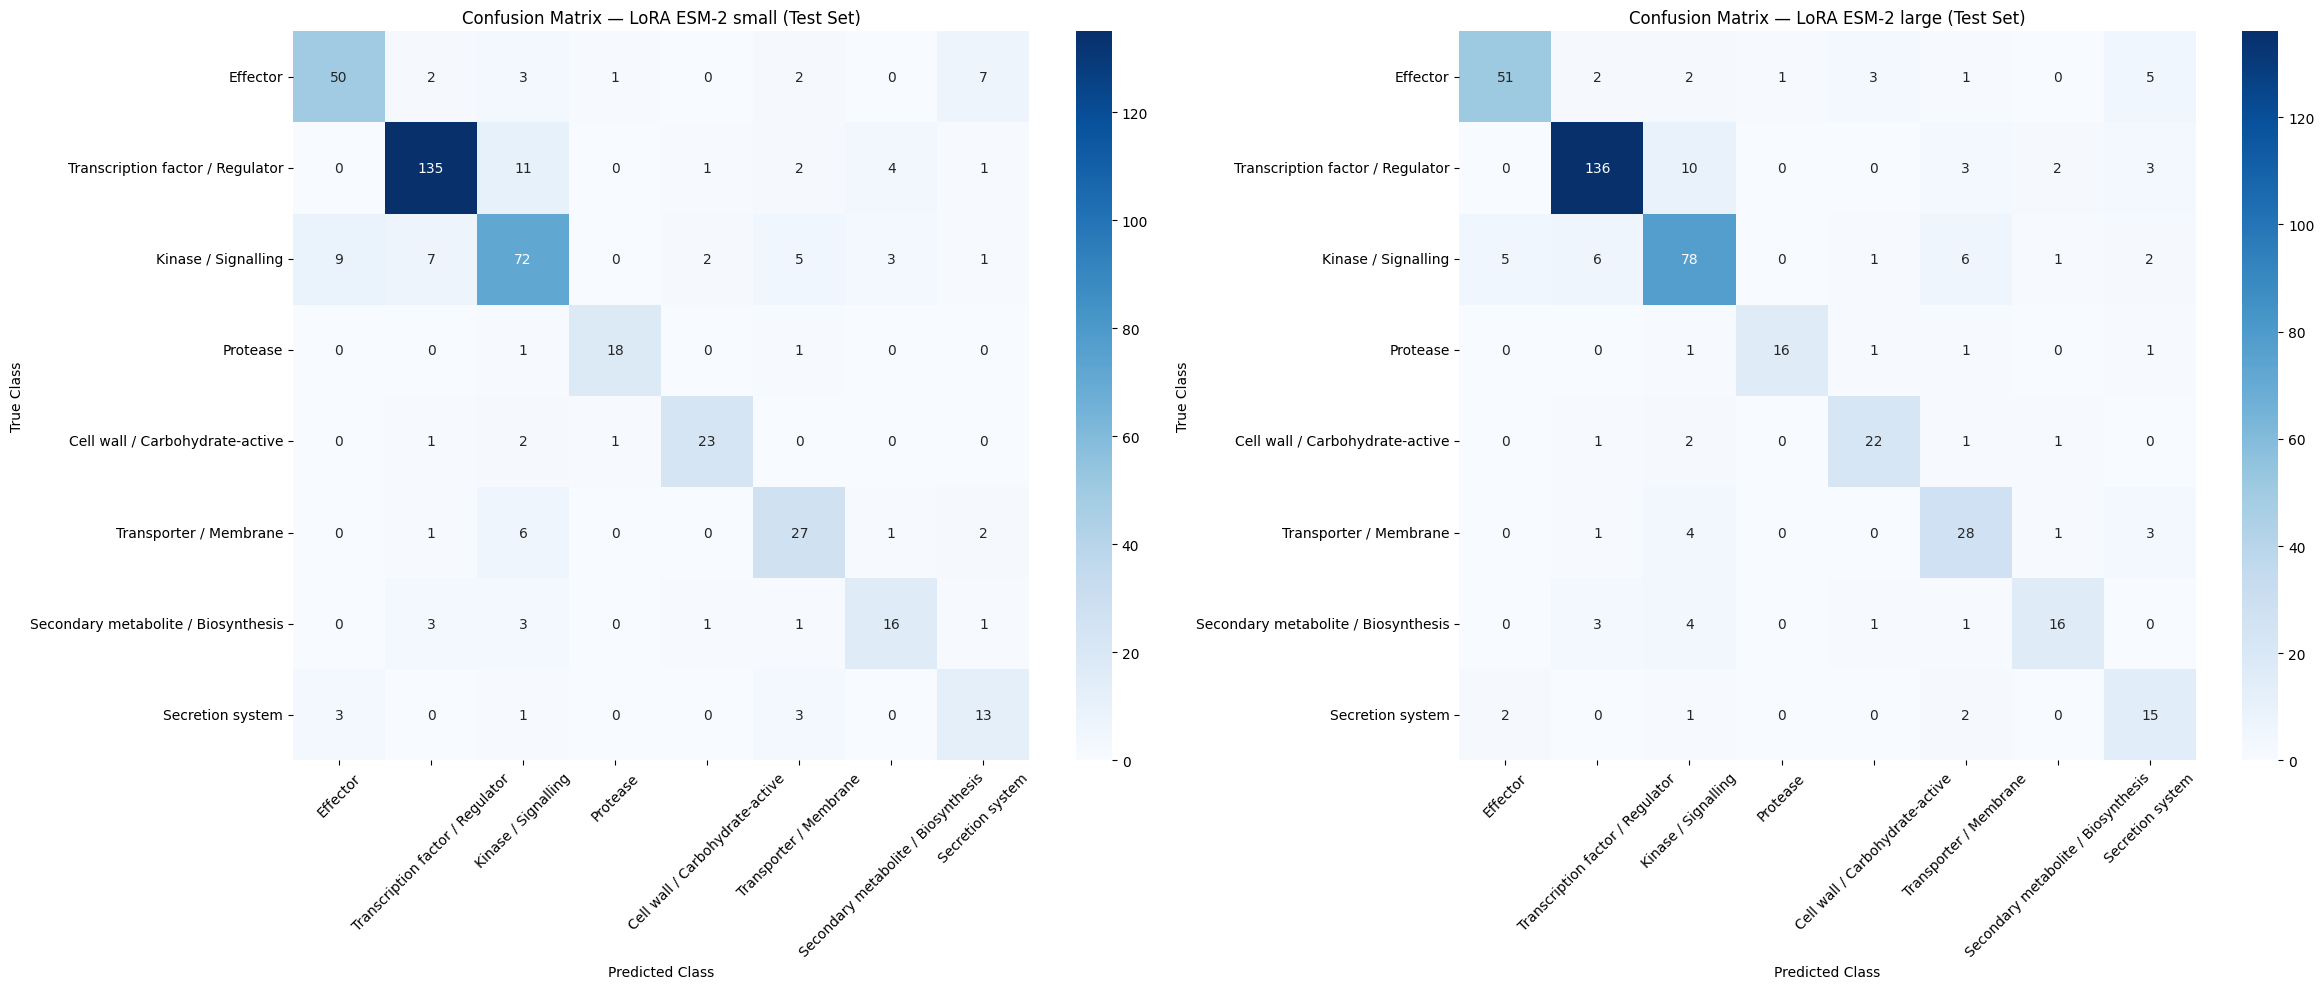

In [8]:
# Confusion matrices — both model sizes
fig, axes = plt.subplots(1, 2, figsize=(24, 10))
for ax, (size, res) in zip(axes, test_results.items()):
    cm = confusion_matrix(test_labels, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix — LoRA ESM-2 {size} (Test Set)')
    ax.set_xlabel('Predicted Class')
    ax.set_ylabel('True Class')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Test set evaluation**: Both models generalise well to the held-out test set, with the large model achieving 81.0% accuracy versus 79.2% for the small model, consistent with the cross-validation gap. Macro F1 scores of 0.760 and 0.772 respectively align closely with CV estimates, indicating no meaningful overfitting.

**Per-class performance**: Transcription factor / Regulator and Protease are the strongest classes (F1 ≥ 0.865 in both models), while Secretion system remains the weakest (F1 ~0.58–0.61). The dominant confusion axis is Kinase / Signalling ↔ Transcription factor / Regulator, and Effector ↔ Secretion system confusion persists as expected given their biological coupling. The large model's main advantage is higher precision across several classes, suggesting fewer false positives rather than meaningfully better recall. Transporter / Membrane and Secondary metabolite / Biosynthesis remain mid-tier challenges, likely reflecting their functional heterogeneity and smaller training sizes.

Effectors are delivered by secretion systems and co-evolve with secretion machinery, so sequence similarity at their interface is expected. Some PHI-base annotations may also label the same protein differently depending on the study's framing.

Two-component signal transduction systems are the key overlap for kinase / transcription factor confusion. Response regulators contain both a phosphoreceiver domain and a DNA-binding domain, straddling both classes at the sequence level. PHI-base entries for these systems are likely annotated inconsistently depending on which functional role a given study emphasised.

In [9]:
# Performance comparison: frozen baseline → LoRA val → LoRA test
frozen_baselines = {'small': {'macro_f1': 0.698, 'accuracy': 0.742},
                    'large': {'macro_f1': 0.733, 'accuracy': 0.773}}
lora_val         = {'small': {'macro_f1': 0.742, 'accuracy': 0.780},
                    'large': {'macro_f1': 0.753, 'accuracy': 0.796}}

for size, res in test_results.items():
    preds = res['preds']
    acc   = accuracy_score(test_labels, preds)
    _, _, f1_per_class, _ = precision_recall_fscore_support(
        test_labels, preds, average=None, zero_division=0
    )
    macro_f1    = np.mean(f1_per_class)
    weighted_f1 = precision_recall_fscore_support(
        test_labels, preds, average='weighted', zero_division=0
    )[2]

    res['accuracy']    = acc
    res['macro_f1']    = macro_f1
    res['weighted_f1'] = weighted_f1
    res['f1_per_class'] = f1_per_class

    fb = frozen_baselines[size]
    lv = lora_val[size]

    print(f"\n{'='*70}")
    print(f"  ESM-2 {size}")
    print(f"{'='*70}")
    print(f"{'Metric':<20} {'Frozen baseline':<20} {'LoRA val (CV)':<20} {'LoRA test set':<20}")
    print("-" * 80)
    print(f"{'Accuracy':<20} {fb['accuracy']*100:.1f}%{'':<14} {lv['accuracy']*100:.1f}%{'':<14} {acc*100:.1f}%")
    print(f"{'Macro F1':<20} {fb['macro_f1']:.3f}{'':<15} {lv['macro_f1']:.3f}{'':<15} {macro_f1:.3f}")
    print(f"{'Weighted F1':<20} {'—':<20} {'—':<20} {weighted_f1:.3f}")

    val_test_drift = macro_f1 - lv['macro_f1']
    print(f"\nVal → Test drift (macro F1): {val_test_drift:+.3f}")
    print(f"{'✓ Generalised well' if abs(val_test_drift) < 0.03 else '⚠ Potential overfitting'}")


  ESM-2 small
Metric               Frozen baseline      LoRA val (CV)        LoRA test set       
--------------------------------------------------------------------------------
Accuracy             74.2%               78.0%               79.2%
Macro F1             0.698                0.742                0.760
Weighted F1          —                    —                    0.794

Val → Test drift (macro F1): +0.018
✓ Generalised well

  ESM-2 large
Metric               Frozen baseline      LoRA val (CV)        LoRA test set       
--------------------------------------------------------------------------------
Accuracy             77.3%               79.6%               81.0%
Macro F1             0.733                0.753                0.772
Weighted F1          —                    —                    0.813

Val → Test drift (macro F1): +0.019
✓ Generalised well


Both models improve consistently from frozen baseline through LoRA fine-tuning to test set evaluation. The small model gains +0.044 macro F1 from fine-tuning versus +0.020 for the large model, narrowing the gap between them from 0.035 to 0.012. Crucially, both models show a small positive drift from CV validation to test set (+0.018/+0.019 macro F1), indicating clean generalisation with no overfitting. The large model remains the stronger performer across all metrics, but the small model's stronger response to fine-tuning makes it the more efficient option if compute is a constraint.

## 3 Confidence and Error Analysis

This section combines confidence analysis with a comprehensive error review. For each model size, we extract softmax confidence scores, assess calibration, and then compile ALL misclassifications — ordered by confidence — with PHI-base metadata for literature review.

Unlike notebook 03 which only reviewed high-confidence errors (>0.9), this section prepares the full error list for reclassification against the literature.

In [10]:
# Confidence analysis for both models
for size, res in test_results.items():
    probs      = torch.softmax(torch.tensor(res['logits']), dim=1).numpy()
    confidence = probs.max(axis=1)
    correct    = (res['preds'] == test_labels)

    res['probs']      = probs
    res['confidence']  = confidence
    res['correct']     = correct

    print(f"\n{size} confidence analysis:")
    print(f"  Mean confidence (correct):      {confidence[correct].mean():.3f}")
    print(f"  Mean confidence (misclassified): {confidence[~correct].mean():.3f}")
    print(f"  Separation:                      {confidence[correct].mean() - confidence[~correct].mean():.3f}")


small confidence analysis:
  Mean confidence (correct):      0.931
  Mean confidence (misclassified): 0.786
  Separation:                      0.145

large confidence analysis:
  Mean confidence (correct):      0.948
  Mean confidence (misclassified): 0.840
  Separation:                      0.109


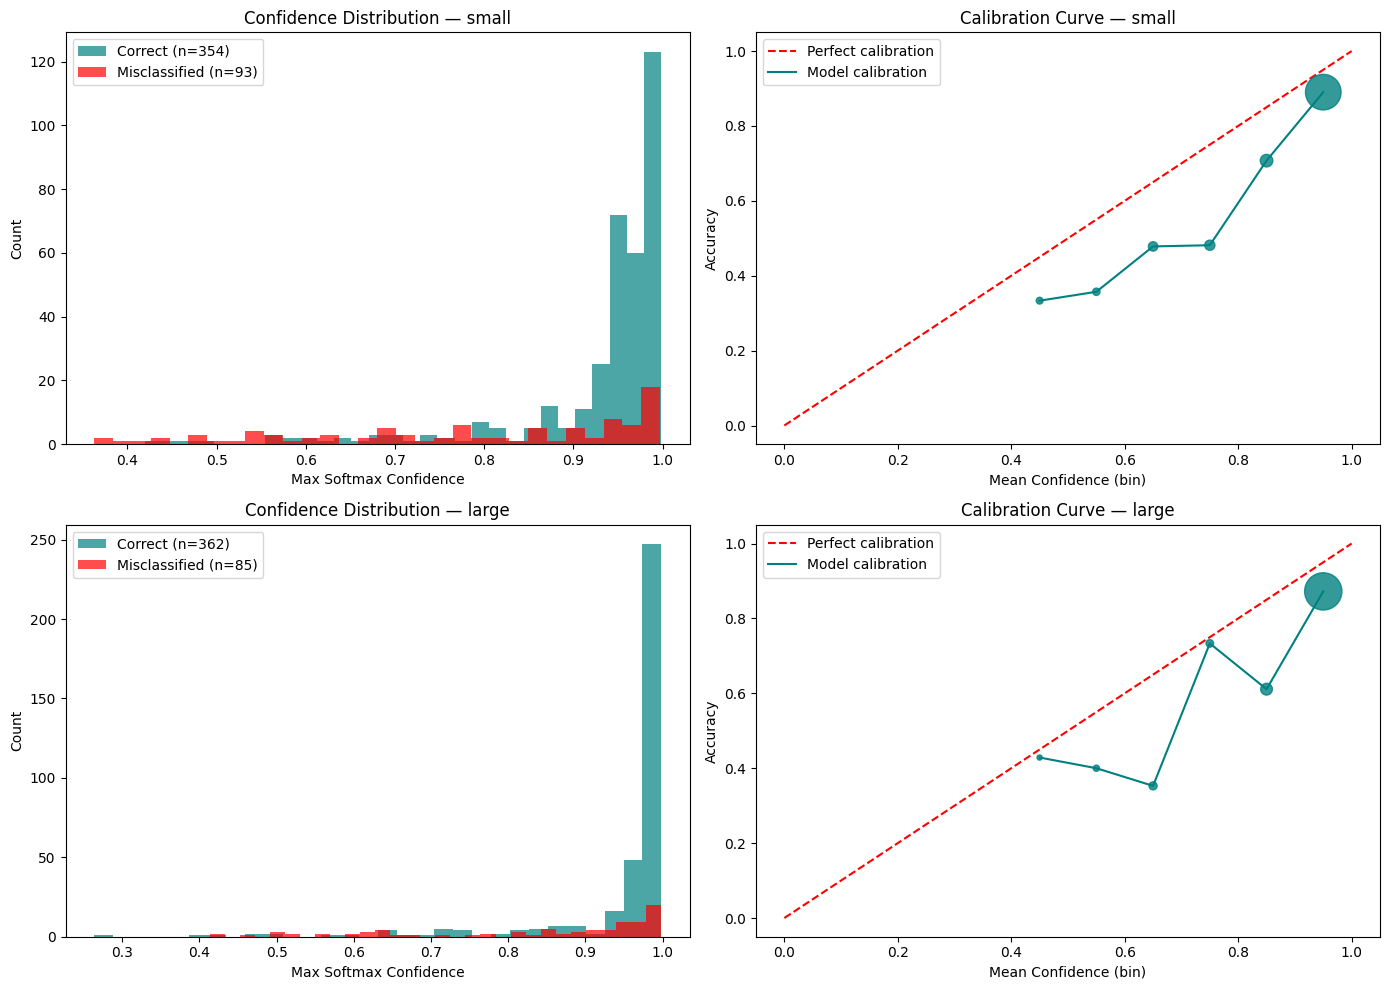

In [11]:
# Confidence distributions and calibration curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (size, res) in enumerate(test_results.items()):
    correct    = res['correct']
    confidence = res['confidence']

    # Histogram
    axes[row][0].hist(confidence[correct],  bins=30, alpha=0.7, color='teal',
                      label=f'Correct (n={correct.sum()})')
    axes[row][0].hist(confidence[~correct], bins=30, alpha=0.7, color='red',
                      label=f'Misclassified (n={(~correct).sum()})')
    axes[row][0].set_title(f'Confidence Distribution — {size}')
    axes[row][0].set_xlabel('Max Softmax Confidence')
    axes[row][0].set_ylabel('Count')
    axes[row][0].legend()

    # Calibration curve
    bin_edges   = np.linspace(0, 1, 11)
    bin_indices = np.digitize(confidence, bin_edges)
    bin_acc, bin_cen, bin_cnt = [], [], []
    for b in range(1, len(bin_edges)):
        mask = bin_indices == b
        if mask.sum() >= 5:
            bin_acc.append(correct[mask].mean())
            bin_cen.append((bin_edges[b-1] + bin_edges[b]) / 2)
            bin_cnt.append(mask.sum())

    axes[row][1].plot([0, 1], [0, 1], 'r--', label='Perfect calibration')
    axes[row][1].scatter(bin_cen, bin_acc, s=[c*2 for c in bin_cnt],
                         color='teal', alpha=0.8, zorder=5)
    axes[row][1].plot(bin_cen, bin_acc, color='teal', label='Model calibration')
    axes[row][1].set_title(f'Calibration Curve — {size}')
    axes[row][1].set_xlabel('Mean Confidence (bin)')
    axes[row][1].set_ylabel('Accuracy')
    axes[row][1].legend()

plt.tight_layout()
plt.show()

Both models are overconfident — predictions cluster heavily above 0.9 softmax confidence, and the calibration curves sit below the diagonal across most bins, meaning stated confidence exceeds actual accuracy at intermediate confidence levels. This is common in fine-tuned transformers without explicit calibration.

Despite this, confidence remains a useful signal. Correct predictions average 0.931/0.948 confidence versus 0.786/0.840 for misclassifications, giving separations of 0.145 (small) and 0.109 (large). The small model actually provides better separation, making it marginally more useful for flagging uncertain predictions. A confidence threshold in practice could filter low-confidence outputs for manual review, though the overlap between correct and misclassified distributions at high confidence means some errors will inevitably pass any reasonable threshold.

In [12]:
# Load raw metadata and parse FASTA to match sequences back to PHI IDs
from Bio import SeqIO

raw_dir       = os.path.join(PROJECT_ROOT, data_config['paths']['raw_dir'])
metadata_path = os.path.join(raw_dir, data_config['paths']['metadata_file'])
fasta_path    = os.path.join(raw_dir, data_config['paths']['fasta_file'])

metadata = pd.read_csv(metadata_path, low_memory=False)

sequences_fasta = {}
for record in SeqIO.parse(fasta_path, "fasta"):
    parts  = record.id.split('#')
    phi_id = next((p for p in parts if p.startswith('PHI:')), None)
    if phi_id:
        sequences_fasta[phi_id] = str(record.seq)

metadata['sequence'] = metadata['PHI_MolConn_ID'].map(sequences_fasta)
df_raw = metadata.dropna(subset=['sequence']).copy()

seq_to_phi      = df_raw.drop_duplicates('sequence').set_index('sequence')['PHI_MolConn_ID'].to_dict()
seq_to_gene     = df_raw.drop_duplicates('sequence').set_index('sequence')['Gene_name'].to_dict()
seq_to_pathogen = df_raw.drop_duplicates('sequence').set_index('sequence')['Pathogen_species'].to_dict()
seq_to_function = df_raw.drop_duplicates('sequence').set_index('sequence')['Function'].to_dict()

print(f"Metadata loaded: {len(df_raw)} records")
print(f"Unique sequences for matching: {len(seq_to_phi)}")

Metadata loaded: 14028 records
Unique sequences for matching: 8536


In [13]:
# Compile ALL misclassifications for the large model (best performing)
# ordered by confidence descending — this is the list for literature review
review_size = 'large'
res = test_results[review_size]

error_mask    = ~res['correct']
error_indices = np.where(error_mask)[0]
error_indices = sorted(error_indices, key=lambda i: res['confidence'][i], reverse=True)

print(f"Total misclassifications ({review_size}): {len(error_indices)}")
print(f"\n{'#':<5} {'PHI ID':<15} {'Gene':<20} {'Pathogen':<30} {'Function':<40} {'True class':<35} {'Predicted':<35} {'Conf.'}")
print("-" * 185)

for rank, i in enumerate(error_indices, 1):
    seq       = test_sequences[i]
    true_cls  = idx_to_class[test_labels[i]]
    pred_cls  = idx_to_class[res['preds'][i]]
    phi_id    = seq_to_phi.get(seq, "unknown")
    gene      = str(seq_to_gene.get(seq, "unknown"))[:18]
    pathogen  = str(seq_to_pathogen.get(seq, "unknown"))[:28]
    function  = str(seq_to_function.get(seq, "unknown"))
    function  = function[:37] + "..." if len(function) > 40 else function
    print(f"{rank:<5} {phi_id:<15} {gene:<20} {pathogen:<30} {function:<40} {true_cls:<35} {pred_cls:<35} {res['confidence'][i]:.3f}")

print(f"\n→ Review the list above against the literature.")
print(f"  Assign each entry one of: 'ambiguous_phi_error', 'ambiguous_dual_function', 'mixed', 'model_error'")
print(f"  Then populate the reclassification dict in the next cell.")

Total misclassifications (large): 85

#     PHI ID          Gene                 Pathogen                       Function                                 True class                          Predicted                           Conf.
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
1     PHI:9239        alg8                 Pseudomonas aeruginosa         alginate biosynthesis protein            Secondary metabolite / Biosynthesis Cell wall / Carbohydrate-active     0.998
2     PHI:123118      SsPG1-1              Sclerotinia sclerotiorum       PG-inhibiting proteins                   Kinase / Signalling                 Cell wall / Carbohydrate-active     0.997
3     PHI:7092        vgrG-1               Erwinia amylovora              T6SS effector protein                    Effector                            Secretion system                    0.995
4   

In [14]:
# Reclassification dict for notebook 04 cell 18
# Paste this into the reclassification = {} cell

reclassification = {
    'PHI:9239':   'ambiguous_phi_error',       # alg8 - GT-2 glycosyltransferase, CW/carb-active not SM
    'PHI:123118': 'ambiguous_phi_error',       # SsPG1-1 - endopolygalacturonase, not kinase
    'PHI:7092':   'ambiguous_dual_function',   # vgrG-1 - T6SS spike + effector
    'PHI:4975':   'mixed',                     # LssB - T1SS ABC transporter component
    'PHI:124139': 'ambiguous_phi_error',       # Zip350 - histone methyltransferase = regulator
    'PHI:5338':   'ambiguous_phi_error',       # tssK-5 - T6SS baseplate, not effector
    'PHI:5257':   'mixed',                     # secY - Sec translocon channel
    'PHI:123702': 'model_error',               # dgkA - diacylglycerol kinase
    'PHI:3756':   'ambiguous_phi_error',       # sifA - T3SS effector, not secretion system
    'PHI:124511': 'ambiguous_phi_error',       # flbC - C2H2 zinc finger TF
    'PHI:1555':   'model_error',               # GzMyb019 - transcription factor
    'PHI:3663':   'ambiguous_phi_error',       # gluP - glucose permease/transporter
    'PHI:5242':   'ambiguous_phi_error',       # ccpE - virulence regulator
    'PHI:7715':   'ambiguous_phi_error',       # MGA_0220 - ABC transporter component
    'PHI:7193':   'mixed',                     # FgLaeA - global regulator of SM
    'PHI:9298':   'ambiguous_phi_error',       # Penlp1 - NLP necrosis effector
    'PHI:125077': 'model_error',               # g2572 - subtilisin-like protease
    'PHI:3333':   'mixed',                     # pga7 - GPI-anchored heme-binding protein
    'PHI:5334':   'ambiguous_phi_error',       # tssF-5 - T6SS baseplate, not effector
    'PHI:7538':   'ambiguous_phi_error',       # FepA - TonB-dependent siderophore receptor
    'PHI:2341':   'ambiguous_phi_error',       # BeNEP1 - NLP necrotrophic effector
    'PHI:10805':  'mixed',                     # cp2 - CP2 domain protein
    'PHI:125233': 'mixed',                     # pilJ - T4P/chemotaxis MCP
    'PHI:123153': 'mixed',                     # NWMN2330 - generic virulence factor
    'PHI:4137':   'mixed',                     # xrp8 - type III effector
    'PHI:4865':   'mixed',                     # FgVam7 - SNARE protein
    'PHI:123562': 'mixed',                     # Slm2 - cytoskeleton regulator
    'PHI:9496':   'model_error',               # yeaB - RNA methyltransferase
    'PHI:1025':   'mixed',                     # bcnoxR - NADPH oxidase regulatory subunit
    'PHI:8915':   'model_error',               # FgVPS32 - ESCRT-III component
    'PHI:11614':  'mixed',                     # cyaB - adenylate cyclase
    'PHI:10956':  'mixed',                     # phoQ - two-component sensor kinase
    'PHI:12073':  'ambiguous_phi_error',       # vWbp - secreted coagulase
    'PHI:5577':   'mixed',                     # esx-3 - T7SS component
    'PHI:11868':  'model_error',               # otsA - trehalose-6-P synthase
    'PHI:123650': 'model_error',               # malM - periplasmic protein
    'PHI:123977': 'model_error',               # lphD - effector protein
    'PHI:12129':  'mixed',                     # bglu_2g07420 - pentapeptide repeat protein
    'PHI:6687':   'mixed',                     # gra10 - dense granule protein
    'PHI:11231':  'model_error',               # SAUSA300_0964 - chitinase-related
    'PHI:10500':  'mixed',                     # tapV - T4P assembly protein
    'PHI:6321':   'ambiguous_phi_error',       # potC - ABC transporter component
    'PHI:124144': 'mixed',                     # RvvA - two-component sensor
    'PHI:7118':   'mixed',                     # gtfA - glycosyltransferase
    'PHI:124082': 'model_error',               # FliY - ABC transporter SBP
    'PHI:4769':   'mixed',                     # HaRxLL470b - RXLR effector
    'PHI:4715':   'mixed',                     # crc - catabolite repression regulator
    'PHI:2489':   'ambiguous_phi_error',       # rsmAXoo - CsrA-family RNA-binding regulator
    'PHI:7136':   'ambiguous_dual_function',   # lcrV - T3SS needle tip + immunomodulator
    'PHI:3725':   'model_error',               # PhoPQ - sensor histidine kinase
    'PHI:6998':   'mixed',                     # BfiS - sensor kinase TCS
    'PHI:12224':  'model_error',               # MoPtep1 - effector protein
    'PHI:12236':  'ambiguous_phi_error',       # VdAda1 - SAGA complex (histone acetyltransferase)
    'PHI:8921':   'mixed',                     # EadM - DNA methyltransferase
    'PHI:123246': 'mixed',                     # EI219_09440 - DUF1836 protein
    'PHI:5258':   'mixed',                     # tfpO - pilin glycosyltransferase
    'PHI:124632': 'mixed',                     # UMAG_10076 - effector
    'PHI:231':    'ambiguous_phi_error',       # RPK1 - PKA regulatory subunit
    'PHI:4960':   'model_error',               # rsmI - rRNA methyltransferase
    'PHI:3120':   'mixed',                     # PSPTO_3331 - proteinase inhibitor
    'PHI:7603':   'ambiguous_phi_error',       # rfbE - O-antigen export ATPase
    'PHI:11210':  'model_error',               # cda7 - chitin deacetylase
    'PHI:6319':   'ambiguous_phi_error',       # potA - ABC transporter ATPase
    'PHI:3593':   'mixed',                     # MgtC - Mg2+ homeostasis
    'PHI:4921':   'model_error',               # flmQ - flagellin glycosyltransferase
    'PHI:3086':   'ambiguous_dual_function',   # prtA - secreted metalloprotease effector
    'PHI:11519':  'mixed',                     # rv3680 - anion transporter ATPase
    'PHI:4834':   'mixed',                     # TceSR - two-component system
    'PHI:11554':  'model_error',               # A1479 - cell envelope amide hydrolase
    'PHI:6568':   'mixed',                     # REP34 - carboxypeptidase
    'PHI:6674':   'mixed',                     # MoTRX2 - thioredoxin oxidoreductase
    'PHI:10789':  'model_error',               # BAB1_0270 - metalloproteinase
    'PHI:11872':  'ambiguous_dual_function',   # cadC - membrane-integrated TF
    'PHI:7667':   'ambiguous_dual_function',   # LysM4 - chitin-binding effector
    'PHI:5109':   'mixed',                     # prt - O-antigen biosynthesis
    'PHI:7478':   'model_error',               # FepB - enterobactin transporter
    'PHI:4223':   'mixed',                     # Pde2 - c-di-AMP phosphodiesterase
    'PHI:4112':   'mixed',                     # MoVELB - velvet family regulator
    'PHI:6097':   'model_error',               # hns - H-NS global regulator
    'PHI:3115':   'mixed',                     # PSPTO_5633 - effector
    'PHI:1683':   'model_error',               # GzRad001 - transcription factor
    'PHI:4633':   'mixed',                     # dgcB - diguanylate cyclase
    'PHI:7298':   'model_error',               # PhzG1 - phenazine biosynthesis
    'PHI:10428':  'mixed',                     # vreR - sigma factor regulator
    'PHI:3417':   'model_error',               # Ohmm - mitochondrial TM protein
}


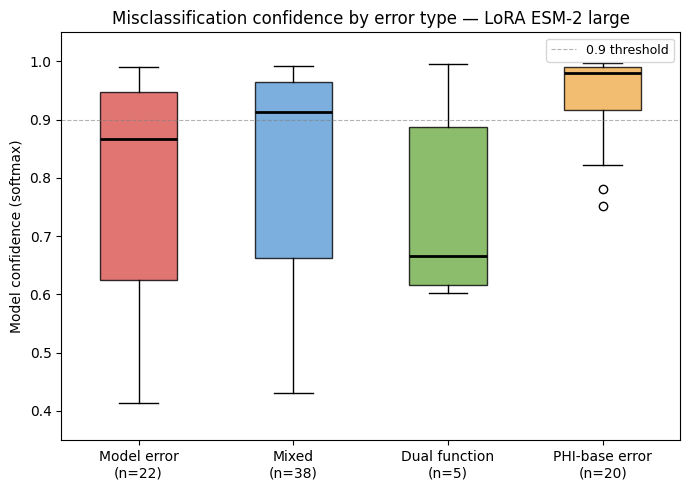

In [23]:
# Build dataframe from existing test_results and reclassification dict
res = test_results['large']
error_mask = ~res['correct']
error_indices = np.where(error_mask)[0]

phi_ids = [seq_to_phi.get(test_sequences[i], 'unknown') for i in error_indices]
confidences = [res['confidence'][i] for i in error_indices]

df_errors = pd.DataFrame({'phi_id': phi_ids, 'confidence': confidences})
df_errors['error_type'] = df_errors['phi_id'].map(reclassification)

label_map = {
    'model_error': 'Model error',
    'mixed': 'Mixed',
    'ambiguous_dual_function': 'Dual function',
    'ambiguous_phi_error': 'PHI-base error',
}
df_errors['label'] = df_errors['error_type'].map(label_map)

order = ['Model error', 'Mixed', 'Dual function', 'PHI-base error']
grouped = [df_errors[df_errors['label'] == cat]['confidence'].values for cat in order]
counts = [len(g) for g in grouped]

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(grouped, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))

colours = ['#d9534f', '#5b9bd5', '#70ad47', '#f0ad4e']
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels([f'{cat}\n(n={counts[i]})' for i, cat in enumerate(order)])
ax.set_ylabel('Model confidence (softmax)')
ax.set_title('Misclassification confidence by error type — LoRA ESM-2 large')
ax.set_ylim(0.35, 1.05)
ax.axhline(0.9, linestyle='--', color='grey', linewidth=0.8, alpha=0.6, label='0.9 threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

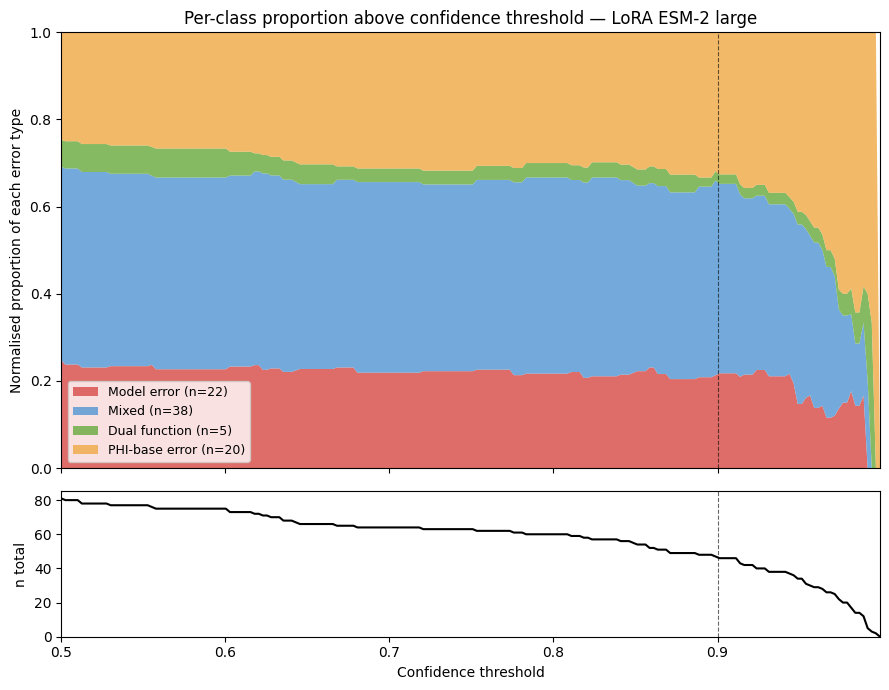

In [35]:
thresholds = np.linspace(0.5, 0.999, 200)

raw = {cat: [] for cat in order}
ns  = []

for t in thresholds:
    above = df_errors[df_errors['confidence'] >= t]
    ns.append(len(above))
    for cat in order:
        raw[cat].append((above['label'] == cat).sum())

raw = {cat: np.array(vals, dtype=float) for cat, vals in raw.items()}
ns  = np.array(ns, dtype=float)

stack = np.array([raw[cat] for cat in order])
totals = stack.sum(axis=0)
totals[totals == 0] = 1  # avoid division by zero
normalised = stack / totals

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.stackplot(thresholds, normalised, labels=[f'{cat} (n={cat_totals[cat]})' for cat in order],
              colors=colours, alpha=0.85)

ax1.set_ylabel('Normalised proportion of each error type')
ax1.set_ylim(0, 1)
ax1.set_xlim(thresholds[0], thresholds[-1])
ax1.legend(loc='lower left', fontsize=9)
ax1.set_title('Per-class proportion above confidence threshold — LoRA ESM-2 large')
ax1.axvline(0.9, linestyle='--', color='black', linewidth=0.8, alpha=0.6)

ax2.plot(thresholds, ns, color='black', linewidth=1.5)
ax2.set_ylabel('n total')
ax2.set_xlabel('Confidence threshold')
ax2.set_xlim(thresholds[0], thresholds[-1])
ax2.set_ylim(0, max(ns) * 1.05)
ax2.axvline(0.9, linestyle='--', color='black', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()

Misclassification confidence by error type: PHI-base annotation errors are predicted with strikingly high confidence — median above 0.95 with a tight interquartile range — meaning the model is making consistent, decisive predictions that simply disagree with the database label. This strongly suggests the model has learned genuine biochemical signal and that the PHI-base annotation is the source of error in these cases, not the model.

Model errors and mixed cases show broader confidence distributions extending well below 0.9, reflecting genuine uncertainty at class boundaries where sequences have ambiguous or multi-functional biology.

Dual function cases show the lowest median confidence (~0.65) and widest spread, which is mechanistically interpretable: proteins with genuine dual-class biology produce competing signals across two classes, diluting the softmax output for either prediction. The low confidence here is therefore not a model failure but an accurate reflection of biological ambiguity.

The threshold analysis confirms this pattern: normalising each error type by its own class size, PHI-base errors become increasingly over-represented above ~0.95 confidence, while dual function cases drop out earliest as the threshold rises. Together, this pattern suggests confidence is a meaningful proxy for error type — high-confidence misclassifications warrant scrutiny of the annotation rather than the model, while low-confidence predictions flag genuinely ambiguous sequences that may require experimental characterisation or multi-label annotation.

# Literature Review of ESM-2 Large Model Misclassifications (Test Set)

## Overview

This document reviews all 85 misclassifications from the LoRA fine-tuned ESM-2 650M model on the held-out test set. Each entry is assessed against peer-reviewed literature and assigned one of four labels:

- **🟢 PHI-base annotation error** — The PHI-base label is wrong; the model prediction better matches the literature.
- **🟢 Dual-function protein** — The protein genuinely straddles two functional categories; both labels are defensible.
- **🟡 Mixed evidence** — Some biological basis for the model's prediction, but the PHI-base label is more accurate overall.
- **🔴 Model error** — The model prediction is clearly wrong with no strong biological justification.

The full markdown document can be found in "/notebooks/Error Review Large Model.md"

---

## Summary Table

### 🟢 PHI-base annotation error (model prediction is correct or more accurate)

| # | PHI ID | Gene | Organism |
|---|--------|------|----------|
| 1 | PHI:9239 | alg8 | *P. aeruginosa* |
| 2 | PHI:123118 | SsPG1-1 | *S. sclerotiorum* |
| 6 | PHI:5338 | tssK-5 | *B. pseudomallei* |
| 9 | PHI:3756 | sifA | *S. enterica* |
| 10 | PHI:124511 | flbC | *F. oxysporum* |
| 12 | PHI:3663 | gluP | *X. fastidiosa* |
| 13 | PHI:5242 | ccpE | *S. aureus* |
| 14 | PHI:7715 | MGA_0220 | *M. gallisepticum* |
| 16 | PHI:9298 | Penlp1 | *P. expansum* |
| 19 | PHI:5334 | tssF-5 | *B. pseudomallei* |
| 20 | PHI:7538 | FepA | *K. pneumoniae* |
| 21 | PHI:2341 | BeNEP1 | *B. elliptica* |
| 33 | PHI:12073 | vWbp | *S. aureus* |
| 42 | PHI:6321 | potC | *S. pneumoniae* |
| 48 | PHI:2489 | rsmAXoo | *X. oryzae* |
| 53 | PHI:12236 | VdAda1 | *V. dahliae* |
| 58 | PHI:231 | RPK1 | *C. lagenaria* |
| 61 | PHI:7603 | rfbE | *B. abortus* |
| 63 | PHI:6319 | potA | *S. pneumoniae* |

Also PHI:124139 (Zip350, #5) where the model's TF/Regulator is closer to the truth than SM/Biosynthesis.

**Total: 20**

### 🟢 Dual-function protein (both labels are biologically defensible)

| # | PHI ID | Gene | Organism |
|---|--------|------|----------|
| 3 | PHI:7092 | vgrG-1 | *E. amylovora* |
| 49 | PHI:7136 | lcrV | *Y. pestis* |
| 66 | PHI:3086 | prtA | *P. luminescens* |
| 73 | PHI:11872 | cadC | *E. tarda* |
| 74 | PHI:7667 | LysM4 | *P. expansum* |

**Total: 5**

### 🟡 Mixed evidence (some biological basis for the model's prediction, but PHI-base is more accurate)

| # | PHI ID | Gene | Organism |
|---|--------|------|----------|
| 4 | PHI:4975 | LssB | *L. pneumophila* |
| 7 | PHI:5257 | secY | *L. monocytogenes* |
| 15 | PHI:7193 | FgLaeA | *F. graminearum* |
| 18 | PHI:3333 | pga7 | *C. albicans* |
| 22 | PHI:10805 | cp2 | *V. dahliae* |
| 23 | PHI:125233 | pilJ | *A. citrulli* |
| 24 | PHI:123153 | NWMN2330 | *S. aureus* |
| 25 | PHI:4137 | xrp8 | *X. oryzae* |
| 26 | PHI:4865 | FgVam7 | *F. graminearum* |
| 27 | PHI:123562 | Slm2 | *E. turcicum* |
| 29 | PHI:1025 | bcnoxR | *B. cinerea* |
| 31 | PHI:11614 | cyaB | *B. burgdorferi* |
| 32 | PHI:10956 | phoQ | *S. maltophilia* |
| 34 | PHI:5577 | esx-3 | *M. tuberculosis* |
| 38 | PHI:12129 | bglu_2g07420 | *B. glumae* |
| 39 | PHI:6687 | gra10 | *T. gondii* |
| 41 | PHI:10500 | tapV | *R. solanacearum* |
| 43 | PHI:124144 | RvvA | *V. cholerae* |
| 44 | PHI:7118 | gtfA | *S. pneumoniae* |
| 46 | PHI:4769 | HaRxLL470b | *H. arabidopsidis* |
| 47 | PHI:4715 | crc | *P. aeruginosa* |
| 51 | PHI:6998 | BfiS | *P. aeruginosa* |
| 54 | PHI:8921 | EadM | *X. axonopodis* |
| 55 | PHI:123246 | EI219_09440 | *S. suis* |
| 56 | PHI:5258 | tfpO | *P. aeruginosa* |
| 57 | PHI:124632 | UMAG_10076 | *U. maydis* |
| 60 | PHI:3120 | PSPTO_3331 | *P. syringae* |
| 64 | PHI:3593 | MgtC | *M. marinum* |
| 67 | PHI:11519 | rv3680 | *M. tuberculosis* |
| 68 | PHI:4834 | TceSR | *B. melitensis* |
| 70 | PHI:6568 | REP34 | *F. tularensis* |
| 71 | PHI:6674 | MoTRX2 | *M. oryzae* |
| 75 | PHI:5109 | prt | *S. enterica* |
| 77 | PHI:4223 | Pde2 | *S. pneumoniae* |
| 78 | PHI:4112 | MoVELB | *M. oryzae* |
| 80 | PHI:3115 | PSPTO_5633 | *P. syringae* |
| 82 | PHI:4633 | dgcB | *B. glumae* |
| 84 | PHI:10428 | vreR | *P. aeruginosa* |

**Total: 38**

### 🔴 Genuine model error (model prediction clearly wrong)

| # | PHI ID | Gene | Organism |
|---|--------|------|----------|
| 8 | PHI:123702 | dgkA | *P. aeruginosa* |
| 11 | PHI:1555 | GzMyb019 | *F. graminearum* |
| 17 | PHI:125077 | g2572 | *A. alternata* |
| 28 | PHI:9496 | yeaB | *S. enterica* |
| 30 | PHI:8915 | FgVPS32 | *F. graminearum* |
| 35 | PHI:11868 | otsA | *A. baumannii* |
| 36 | PHI:123650 | malM | *E. coli* |
| 37 | PHI:123977 | lphD | *L. pneumophila* |
| 40 | PHI:11231 | SAUSA300_0964 | *S. aureus* |
| 45 | PHI:124082 | FliY | *A. pleuropneumoniae* |
| 50 | PHI:3725 | PhoPQ | *S. enterica* |
| 52 | PHI:12224 | MoPtep1 | *M. oryzae* |
| 59 | PHI:4960 | rsmI | *S. aureus* |
| 62 | PHI:11210 | cda7 | *U. maydis* |
| 65 | PHI:4921 | flmQ | *B. cenocepacia* |
| 69 | PHI:11554 | A1479 | *B. melitensis* |
| 72 | PHI:10789 | BAB1_0270 | *B. abortus* |
| 76 | PHI:7478 | FepB | *K. pneumoniae* |
| 79 | PHI:6097 | hns | *K. pneumoniae* |
| 81 | PHI:1683 | GzRad001 | *F. graminearum* |
| 83 | PHI:7298 | PhzG1 | *P. aeruginosa* |
| 85 | PHI:3417 | Ohmm | *B. bassiana* |

**Total: 22**

---

## Summary Statistics

| Category | Count | Percentage |
|----------|-------|------------|
| 🟢 PHI-base annotation error | 20 | 23.5% |
| 🟢 Dual-function protein | 5 | 5.9% |
| 🟡 Mixed evidence | 38 | 44.7% |
| 🔴 Model error | 22 | 25.9% |
| **Total** | **85** | **100%** |

---

## Key Findings

**Nearly a quarter of all errors reflect PHI-base annotation problems rather than model failures.** Twenty of 85 misclassifications (23.5%) are cases where the model's prediction is more consistent with the literature than the PHI-base label. The most prominent patterns include ABC transporters mislabelled as "Kinase / Signalling" (potA, potC, MGA_0220, rfbE), T6SS structural components labelled as "Effector" (tssK-5, tssF-5), siderophore transporters labelled as "Secondary metabolite / Biosynthesis" (FepA), and proteins with clear transcription factor function mislabelled in other categories (flbC, ccpE, rsmAXoo, RPK1).

**Five cases represent genuine dual-function proteins** where both the PHI-base label and the model prediction capture valid aspects of the protein's biology. The recurring pattern of secretion system structural components that also function as effectors (VgrG, LcrV) and protease-effectors (PrtA) is consistent with the previous high-confidence analysis.

**The mixed evidence category is the largest (44.7%)**, reflecting the genuine biological ambiguity in assigning proteins to discrete functional classes. The most common pattern is the Kinase/Signalling ↔ TF/Regulator confusion, driven by two-component system proteins that bridge both categories, and the Effector ↔ Secretion system confusion, driven by proteins at the interface of secretion apparatus and translocated substrates.

**Model errors are concentrated in specific failure modes.** Of 22 genuine model errors, several patterns emerge: ESCRT/vesicle trafficking proteins misclassified as Kinase/Signalling (FgVPS32), subtilisin-like proteases misclassified as Kinase/Signalling (g2572), cell wall enzymes misclassified as Kinase/Signalling (flmQ, cda7, SAUSA300_0964), and several low-confidence predictions (≤0.5) that are essentially random guesses (GzRad001, PhzG1, Ohmm).

**Confidence is a reliable indicator of error type.** High-confidence errors (>0.95) are disproportionately PHI-base annotation errors, while low-confidence errors (<0.6) are more likely to be genuine model errors. This supports using model confidence as a quality filter in production deployment.


In [36]:
# Count by label
from collections import Counter
label_counts = Counter(reclassification.values())

print("Reclassification summary:")
print(f"  🟢 PHI-base annotation error (model correct): {label_counts['ambiguous_phi_error']}")
print(f"  🟢 Genuine dual-function protein:             {label_counts['ambiguous_dual_function']}")
print(f"  🟡 Mixed evidence:                            {label_counts['mixed']}")
print(f"  🔴 Model error:                               {label_counts['model_error']}")
print(f"  Total reviewed:                               {sum(label_counts.values())}")

Reclassification summary:
  🟢 PHI-base annotation error (model correct): 20
  🟢 Genuine dual-function protein:             5
  🟡 Mixed evidence:                            38
  🔴 Model error:                               22
  Total reviewed:                               85


In [37]:
# Accuracy recalculation
total        = len(test_labels)   # use test set totals
n_correct    = int(correct.sum())
n_incorrect  = int((~correct).sum())

phi_errors      = label_counts['ambiguous_phi_error']
dual_function   = label_counts['ambiguous_dual_function']
n_mixed         = label_counts['mixed']
n_model_error   = label_counts['model_error']

# Conservative: only clear PHI-base annotation errors flip to correct
conservative_correct = n_correct + phi_errors
conservative_acc     = conservative_correct / total

# Liberal: all biological ambiguity cases (phi errors + dual function) flip to correct
liberal_correct = n_correct + phi_errors + dual_function
liberal_acc     = liberal_correct / total

# Upper bound: only true model errors counted as wrong
upper_bound_correct = total - n_model_error - (n_incorrect - sum(label_counts.values()))
upper_bound_acc     = upper_bound_correct / total

print("Accuracy recalculation after literature review:")
print(f"\n{'Scenario':<55} {'Correct':<10} {'Accuracy':<12} {'vs reported'}")
print("-" * 90)
print(f"{'Reported (all misclassifications counted)':<55} {n_correct:<10} {n_correct/total*100:.1f}%      {'—'}")
print(f"{'Conservative (PHI-base errors only)':<55} {conservative_correct:<10} {conservative_acc*100:.1f}%      {(conservative_acc - n_correct/total)*100:+.1f}%")
print(f"{'Liberal (all biological ambiguity cases)':<55} {liberal_correct:<10} {liberal_acc*100:.1f}%      {(liberal_acc - n_correct/total)*100:+.1f}%")
print(f"{'Upper bound (true model errors only)':<55} {upper_bound_correct:<10} {upper_bound_acc*100:.1f}%      {(upper_bound_acc - n_correct/total)*100:+.1f}%")

print(f"""
Key finding: ~{phi_errors} of {sum(label_counts.values())} high-confidence errors ({phi_errors/sum(label_counts.values())*100:.0f}%)
appear to reflect PHI-base annotation noise rather than genuine model failures.
True accuracy on correctly annotated sequences is likely {conservative_acc*100:.1f}–{liberal_acc*100:.1f}%.
""")

Accuracy recalculation after literature review:

Scenario                                                Correct    Accuracy     vs reported
------------------------------------------------------------------------------------------
Reported (all misclassifications counted)               362        81.0%      —
Conservative (PHI-base errors only)                     382        85.5%      +4.5%
Liberal (all biological ambiguity cases)                387        86.6%      +5.6%
Upper bound (true model errors only)                    425        95.1%      +14.1%

Key finding: ~20 of 85 high-confidence errors (24%)
appear to reflect PHI-base annotation noise rather than genuine model failures.
True accuracy on correctly annotated sequences is likely 85.5–86.6%.



Reclassification summary: Literature review of the 85 large model misclassifications reveals that only 22 (26%) are clear model errors. A further 38 are mixed cases where biological ambiguity makes the correct label genuinely uncertain, and 20 are likely PHI-base annotation errors where the model's prediction is arguably more correct than the database label.

Correcting for annotation noise gives a conservative accuracy estimate of 85.5%, rising to 86.6% if mixed cases are also excluded. The 95.1% upper bound — assuming all non-model-error cases are correct — is likely too generous given the mixed category, but the true accuracy on well-annotated sequences probably lies in the 85–87% range. This suggests reported accuracy substantially underestimates real-world performance on correctly labelled data, a known issue when benchmarking against noisy databases like PHI-base.

On the frozen-weight baseline modles

In [38]:
import pickle, os, jax, jax.numpy as jnp
import flax.linen as nn
import numpy as np
from sklearn.metrics import classification_report, f1_score
from transformers import EsmModel, AutoTokenizer
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Redefine VirulenceClassifier — matches notebook 02 exactly
class VirulenceClassifier(nn.Module):
    num_classes: int = 8
    hidden_dim:  int = 640
    layer_1_dim: int = 256
    layer_2_dim: int = 128
    dropout_rate: float = 0.1

    @nn.compact
    def __call__(self, esm_embeddings, attention_mask=None, training=False):
        if attention_mask is not None:
            mask = attention_mask[:, :, None]
            pooled = (esm_embeddings * mask).sum(axis=1) / mask.sum(axis=1)
        else:
            pooled = jnp.mean(esm_embeddings, axis=1)
        x = nn.Dense(self.layer_1_dim)(pooled)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic=not training)(x)
        x = nn.Dense(self.layer_2_dim)(x)
        x = nn.relu(x)
        x = nn.Dropout(self.dropout_rate, deterministic=not training)(x)
        return nn.Dense(self.num_classes)(x)

def extract_test_embeddings(sequences, esm_model_name, device, batch_size=16, max_length=1022):
    tok = AutoTokenizer.from_pretrained(esm_model_name)
    esm = EsmModel.from_pretrained(esm_model_name).to(device).eval()
    all_embs, all_masks = [], []
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch = tok(sequences[i:i+batch_size], return_tensors='pt',
                        padding=True, truncation=True, max_length=max_length).to(device)
            out = esm(**batch)
            all_embs.append(out.last_hidden_state.cpu().numpy())
            all_masks.append(batch['attention_mask'].cpu().numpy())
    max_len = max(e.shape[1] for e in all_embs)
    hidden  = all_embs[0].shape[-1]
    padded_embs  = np.zeros((len(sequences), max_len, hidden))
    padded_masks = np.zeros((len(sequences), max_len))
    idx = 0
    for emb, mask in zip(all_embs, all_masks):
        n = emb.shape[0]
        padded_embs[idx:idx+n,  :emb.shape[1]]  = emb
        padded_masks[idx:idx+n, :mask.shape[1]] = mask
        idx += n
    return padded_embs, padded_masks

checkpoint_dir = os.path.join(PROJECT_ROOT, 'data/checkpoints')
frozen_test_results = {}

for size in ['small', 'large']:
    print(f"\nRunning frozen baseline inference on test set — {size}...")

    esm_model_name = model_config['model']['models'][size]
    hidden_dim     = model_config['model']['hidden_dims'][size]

    test_embs_np, test_masks_np = extract_test_embeddings(
        test_sequences, esm_model_name, device)

    param_path = os.path.join(checkpoint_dir, f'baseline_{size}_fold1.pkl')
    print(f"  Loading params: {param_path}")
    with open(param_path, 'rb') as f:
        best_params = pickle.load(f)

    classifier = VirulenceClassifier(
        num_classes=model_config['model']['num_classes'],
        hidden_dim=hidden_dim,
        layer_1_dim=model_config['classification_head']['layer_1_dim'],
        layer_2_dim=model_config['classification_head']['layer_2_dim'],
        dropout_rate=model_config['model']['dropout_rate'],
    )

    batch_size = 32
    all_logits = np.concatenate([
        np.array(classifier.apply(
            best_params,
            jnp.array(test_embs_np[i:i+batch_size]),
            jnp.array(test_masks_np[i:i+batch_size]),
            training=False
        ))
        for i in range(0, len(test_sequences), batch_size)
    ], axis=0)

    preds   = np.argmax(all_logits, axis=1)
    correct = preds == test_labels

    frozen_test_results[size] = {
        'preds':        preds,
        'correct':      correct,
        'accuracy':     correct.mean(),
        'macro_f1':     f1_score(test_labels, preds, average='macro'),
        'weighted_f1':  f1_score(test_labels, preds, average='weighted'),
        'f1_per_class': f1_score(test_labels, preds, average=None),
    }

    print(f"\n{size} frozen test set classification report:")
    print(classification_report(test_labels, preds, target_names=class_names, digits=3))

# Summary comparison
print("\nFrozen vs LoRA — test set:")
print(f"\n{'Model':<10} {'Metric':<20} {'Frozen (test)':<20} {'LoRA (test)':<20} {'Change'}")
print("=" * 75)
for size in ['small', 'large']:
    fr = frozen_test_results[size]
    lo = test_results[size]
    print(f"{size:<10} {'Accuracy':<20} {fr['accuracy']*100:.1f}%{'':<15} {lo['accuracy']*100:.1f}%{'':<15} {(lo['accuracy']-fr['accuracy'])*100:+.1f}%")
    print(f"{'':<10} {'Macro F1':<20} {fr['macro_f1']:.3f}{'':<16} {lo['macro_f1']:.3f}{'':<16} {lo['macro_f1']-fr['macro_f1']:+.3f}")
    print()

print(f"\nPer-class F1 — frozen vs LoRA test set (large model):")
print(f"{'Class':<40} {'Frozen (test)':<18} {'LoRA (test)':<18} {'Change'}")
print("-" * 80)
for cls_idx in range(model_config['model']['num_classes']):
    cls_name  = idx_to_class[cls_idx]
    frozen_f1 = frozen_test_results['large']['f1_per_class'][cls_idx]
    lora_f1   = test_results['large']['f1_per_class'][cls_idx]
    change    = lora_f1 - frozen_f1
    arrow     = '↑' if change > 0 else '↓'
    print(f"{cls_name:<40} {frozen_f1:<18.3f} {lora_f1:<18.3f} {arrow}{abs(change):.3f}")


Running frozen baseline inference on test set — small...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Loading params: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_small_fold1.pkl

small frozen test set classification report:
                                     precision    recall  f1-score   support

                           Effector      0.779     0.815     0.797        65
   Transcription factor / Regulator      0.894     0.818     0.854       154
                Kinase / Signalling      0.792     0.576     0.667        99
                           Protease      0.667     0.700     0.683        20
    Cell wall / Carbohydrate-active      0.700     0.778     0.737        27
             Transporter / Membrane      0.614     0.730     0.667        37
Secondary metabolite / Biosynthesis      0.390     0.640     0.485        25
                   Secretion system      0.433     0.650     0.520        20

                           accuracy                          0.732       447
                          macro avg      0.659     0.713     0.676       447
     

Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Loading params: /content/drive/MyDrive/esm-phi-effector/data/checkpoints/baseline_large_fold1.pkl

large frozen test set classification report:
                                     precision    recall  f1-score   support

                           Effector      0.820     0.769     0.794        65
   Transcription factor / Regulator      0.875     0.864     0.869       154
                Kinase / Signalling      0.775     0.626     0.693        99
                           Protease      0.882     0.750     0.811        20
    Cell wall / Carbohydrate-active      0.706     0.889     0.787        27
             Transporter / Membrane      0.646     0.838     0.729        37
Secondary metabolite / Biosynthesis      0.481     0.520     0.500        25
                   Secretion system      0.500     0.700     0.583        20

                           accuracy                          0.765       447
                          macro avg      0.711     0.744     0.721       447
     

Frozen vs LoRA test set comparison: LoRA fine-tuning improves both models substantially over the frozen baseline. The small model gains +6.0% accuracy and +0.084 macro F1, and the large model gains +4.5% accuracy and +0.051 macro F1.

Per-class, the largest gains for the large model are in Secondary metabolite / Biosynthesis (+0.196) and Kinase / Signalling (+0.083) — both classes identified as challenging during prototyping due to functional heterogeneity. The only regression is Transporter / Membrane (-0.029), which remains a mid-tier class in both models. Consistent improvement across nearly all classes confirms that LoRA adaptation is learning genuinely transferable biochemical signal rather than class-specific overfitting.

## 4 Error Analysis

This section performs top-2 prediction analysis, confusion pattern characterisation, and truncation analysis on the test set for both model sizes, consistent with the analysis in notebook 03.

In [39]:
# Top-2 prediction analysis
for size, res in test_results.items():
    logits = res['logits']
    preds  = res['preds']

    top2         = np.argsort(logits, axis=1)[:, ::-1][:, :2]
    top2_correct = top2[:, 1] == test_labels
    correct      = res['correct']
    top1_or_top2 = correct | top2_correct
    n_wrong      = (~correct).sum()

    print(f"\nTop-2 analysis — ESM-2 {size}:")
    print(f"  Top-1 accuracy:                  {correct.mean()*100:.1f}%")
    print(f"  Top-2 accuracy (either correct): {top1_or_top2.mean()*100:.1f}%")
    print(f"\n  Of the {n_wrong} misclassified sequences:")
    print(f"    2nd guess correct: {top2_correct[~correct].sum()} ({top2_correct[~correct].mean()*100:.1f}%)")
    print(f"    2nd guess wrong:   {(~top2_correct[~correct]).sum()} ({(~top2_correct[~correct]).mean()*100:.1f}%)")
    print(f"    Random chance (1 in 7): 14.3%")

    # Most common confusion patterns
    confusion_pairs = Counter()
    for true, pred1, pred2 in zip(
        test_labels[~correct], top2[~correct, 0], top2[~correct, 1]
    ):
        confusion_pairs[(idx_to_class[true], idx_to_class[pred1], idx_to_class[pred2])] += 1

    print(f"\n  Most common confusion patterns:")
    print(f"  {'True':<35} {'1st guess':<35} {'2nd guess':<35} {'2nd=true?':<10} {'Count'}")
    print("  " + "-" * 120)
    for (true, pred1, pred2), count in confusion_pairs.most_common(10):
        second_correct = "✓" if pred2 == true else "✗"
        print(f"  {true:<35} {pred1:<35} {pred2:<35} {second_correct:<10} {count}")

    res['top1_or_top2'] = top1_or_top2


Top-2 analysis — ESM-2 small:
  Top-1 accuracy:                  79.2%
  Top-2 accuracy (either correct): 88.8%

  Of the 93 misclassified sequences:
    2nd guess correct: 43 (46.2%)
    2nd guess wrong:   50 (53.8%)
    Random chance (1 in 7): 14.3%

  Most common confusion patterns:
  True                                1st guess                           2nd guess                           2nd=true?  Count
  ------------------------------------------------------------------------------------------------------------------------
  Transcription factor / Regulator    Kinase / Signalling                 Transcription factor / Regulator    ✓          10
  Kinase / Signalling                 Effector                            Kinase / Signalling                 ✓          7
  Kinase / Signalling                 Transporter / Membrane              Kinase / Signalling                 ✓          5
  Kinase / Signalling                 Transcription factor / Regulator    Kinase / Signallin

Top-2 analysis: Both models recover the correct class as their second prediction at well above chance — 46.2% (small) and 52.9% (large) of misclassifications have the true label as the runner-up, versus 14.3% expected at random. This pushes top-2 accuracy to 88.8% and 91.1% respectively, indicating that most errors reflect boundary uncertainty rather than fundamentally wrong predictions.

The confusion patterns are consistent across both models and dominated by the expected axes: Transcription factor / Regulator ↔ Kinase / Signalling is the single most common pattern in both, and Kinase / Signalling features heavily as either the first or second guess across multiple rows, suggesting the model treats it as a residual category for functionally ambiguous sequences. Effector ↔ Secretion system confusion persists but the correct class is recovered at second position in most cases, reinforcing that these are boundary errors rather than arbitrary failures.

In [40]:
# Get indices of dual function misclassifications
dual_phi_ids = [phi_id for phi_id, etype in reclassification.items()
                if etype == 'ambiguous_dual_function']

res = test_results['large']
error_indices = np.where(~res['correct'])[0]

print(f"{'PHI ID':<15} {'Gene':<20} {'True':<35} {'1st pred':<35} {'2nd pred':<35} {'1st conf':>9} {'2nd conf':>9} {'2nd=true?'}")
print("-" * 175)

for i in error_indices:
    seq = test_sequences[i]
    phi_id = seq_to_phi.get(seq, 'unknown')
    if phi_id not in dual_phi_ids:
        continue

    true_cls  = idx_to_class[test_labels[i]]
    probs     = res['probs'][i]  # full softmax distribution
    top2_idx  = np.argsort(probs)[::-1][:2]
    pred1     = idx_to_class[top2_idx[0]]
    pred2     = idx_to_class[top2_idx[1]]
    conf1     = probs[top2_idx[0]]
    conf2     = probs[top2_idx[1]]
    match     = '✓' if pred2 == true_cls else '✗'
    gene      = str(seq_to_gene.get(seq, 'unknown'))[:18]

    print(f"{phi_id:<15} {gene:<20} {true_cls:<35} {pred1:<35} {pred2:<35} {conf1:>9.3f} {conf2:>9.3f} {match}")

PHI ID          Gene                 True                                1st pred                            2nd pred                             1st conf  2nd conf 2nd=true?
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
PHI:7667        LysM4                Effector                            Cell wall / Carbohydrate-active     Effector                                0.602     0.330 ✓
PHI:7092        vgrG-1               Effector                            Secretion system                    Effector                                0.995     0.002 ✓
PHI:7136        lcrV                 Secretion system                    Effector                            Secretion system                        0.888     0.095 ✓
PHI:3086        prtA                 Effector                            Protease                            Cell wall / Carbohydrate-active        

Top-2 analysis of dual-function cases: of the five dual-function misclassifications, three recover the true class as the second prediction. However, only LysM4 (PHI:7667) shows genuinely close confidences between first and second predictions (0.602 vs 0.330), consistent with true model uncertainty between two biologically reasonable classes. vgrG-1 and lcrV recover the correct class second but with large confidence gaps (0.995/0.002 and 0.888/0.095), indicating the model is committed to one interpretation rather than uncertain between two. prtA and cadC fail to recover the true class at second position, with second predictions that do not reflect the annotated function. These results suggest that within the dual-function category, only a subset exhibit the low-confidence, competing-signal profile expected of genuinely ambiguous sequences.


small truncation analysis:
  Truncated (>1022 aa): 12 (2.7%)
  Accuracy on truncated:       83.3%
  Accuracy on full-length:     79.1%

large truncation analysis:
  Truncated (>1022 aa): 12 (2.7%)
  Accuracy on truncated:       91.7%
  Accuracy on full-length:     80.7%


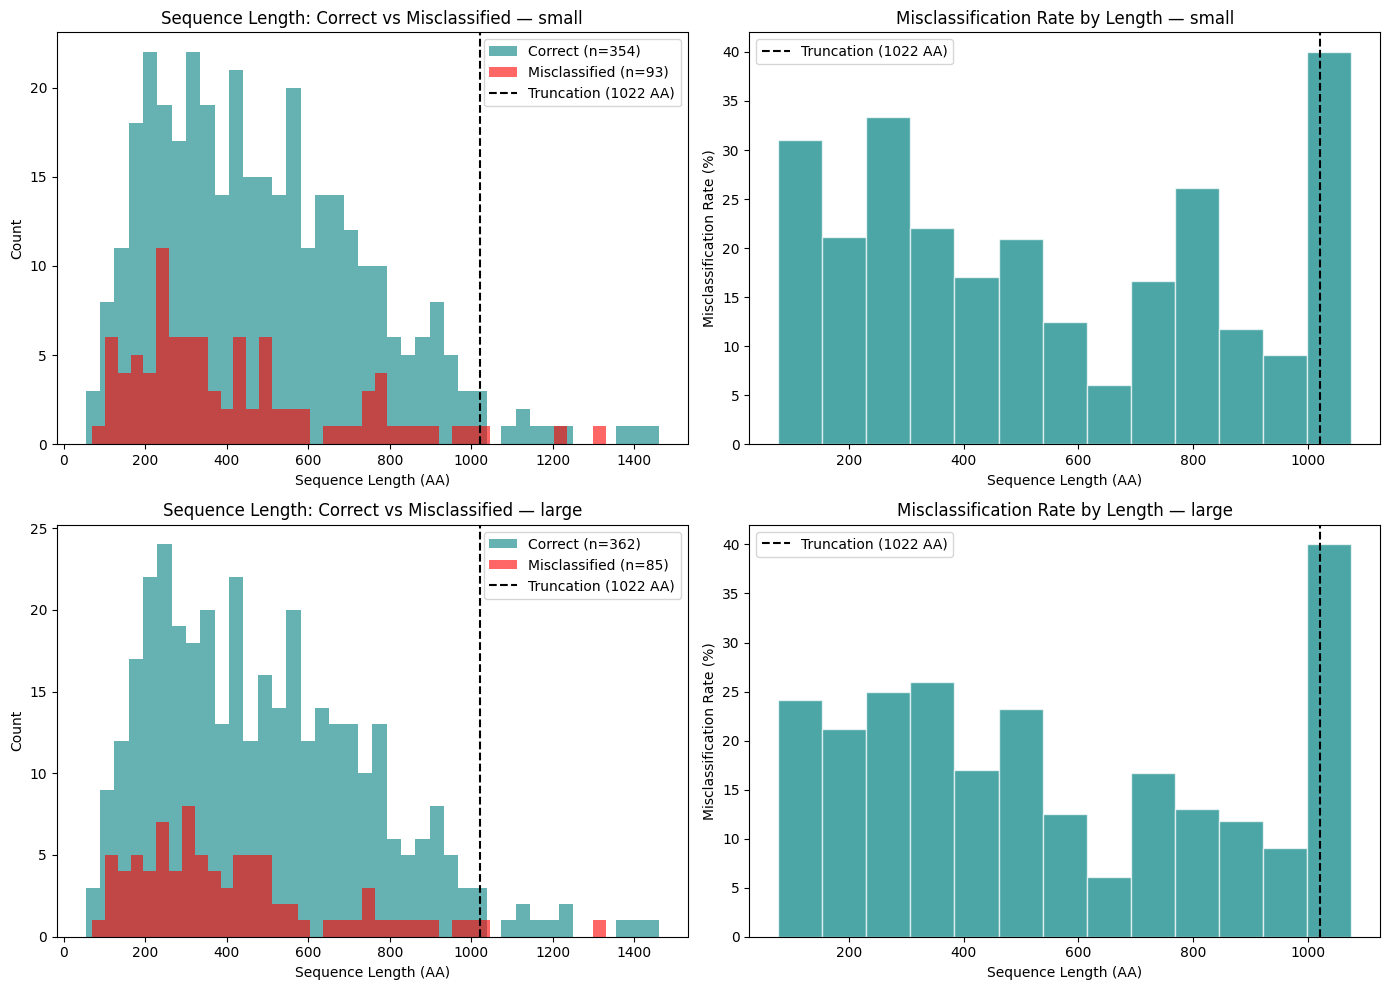

In [41]:
# Truncation analysis
MAX_LEN     = model_config['memory']['max_token_length']
seq_lengths = np.array([len(s) for s in test_sequences])
truncated   = seq_lengths > (MAX_LEN - 2)

fig, axes = plt.subplots(len(test_results), 2,
                         figsize=(14, 5 * len(test_results)))
if len(test_results) == 1:
    axes = [axes]

for row, (size, res) in enumerate(test_results.items()):
    correct = res['correct']

    print(f"\n{size} truncation analysis:")
    print(f"  Truncated (>{MAX_LEN-2} aa): {truncated.sum()} ({truncated.mean()*100:.1f}%)")
    if truncated.sum() > 0:
        print(f"  Accuracy on truncated:       {correct[truncated].mean()*100:.1f}%")
    print(f"  Accuracy on full-length:     {correct[~truncated].mean()*100:.1f}%")

    axes[row][0].hist(seq_lengths[correct],  bins=40, alpha=0.6, color='teal',
                      label=f'Correct (n={correct.sum()})')
    axes[row][0].hist(seq_lengths[~correct], bins=40, alpha=0.6, color='red',
                      label=f'Misclassified (n={(~correct).sum()})')
    axes[row][0].axvline(x=MAX_LEN-2, color='black', linestyle='--',
                         label=f'Truncation ({MAX_LEN-2} AA)')
    axes[row][0].set_title(f'Sequence Length: Correct vs Misclassified — {size}')
    axes[row][0].set_xlabel('Sequence Length (AA)')
    axes[row][0].set_ylabel('Count')
    axes[row][0].legend()

    bin_edges   = np.linspace(0, seq_lengths.max(), 20)
    bin_indices = np.digitize(seq_lengths, bin_edges)
    bin_err, bin_cen = [], []
    for b in range(1, len(bin_edges)):
        mask = bin_indices == b
        if mask.sum() >= 5:
            bin_err.append((~correct[mask]).mean() * 100)
            bin_cen.append((bin_edges[b-1] + bin_edges[b]) / 2)

    axes[row][1].bar(bin_cen, bin_err, width=bin_edges[1]-bin_edges[0],
                     color='teal', alpha=0.7, edgecolor='white')
    axes[row][1].axvline(x=MAX_LEN-2, color='black', linestyle='--',
                         label=f'Truncation ({MAX_LEN-2} AA)')
    axes[row][1].set_title(f'Misclassification Rate by Length — {size}')
    axes[row][1].set_xlabel('Sequence Length (AA)')
    axes[row][1].set_ylabel('Misclassification Rate (%)')
    axes[row][1].legend()

plt.tight_layout()
plt.show()

Truncation analysis: only 2.7% of test sequences exceed the 1,022 AA token limit, and truncation does not negatively impact performance — accuracy on truncated sequences is 83.3% (small) and 91.7% (large), both above their respective full-length accuracies of 79.1% and 80.7%. The misclassification rate by length shows no systematic trend below the truncation threshold, with errors distributed across all length bins. The elevated rate at the truncation boundary reflects the small number of sequences in that bin rather than a truncation effect. Sequence length is therefore not a meaningful source of error in this dataset.

## 5 Within-Class Sequence Diversity Analysis

This section quantifies sequence diversity within each functional class by clustering at multiple lower identity thresholds (30%, 40%, 50%). Unlike the 90% threshold used for redundancy reduction in data curation, lower thresholds detect meaningful functional family boundaries. If Kinase / Signalling is genuinely more diverse than other classes, it should fragment into more clusters at these thresholds, providing a mechanistic explanation for why it acts as a confusion gravity well.

In [42]:
import subprocess
import shutil
from numpy.polynomial.polynomial import polyfit
from scipy.stats import pearsonr
from Bio import SeqIO

# Load all splits to build full sequence set
splits_dir = os.path.join(PROJECT_ROOT, data_config['paths']['splits_dir'])
df_train   = pd.read_csv(os.path.join(splits_dir, "train.csv"))

all_sequences = df_train['sequence'].tolist() + df_test['sequence'].tolist()
all_labels    = df_train['label'].tolist() + df_test['label'].tolist()

# Match sequences back to PHI IDs
fasta_path = os.path.join(PROJECT_ROOT, data_config['paths']['raw_dir'],
                          data_config['paths']['fasta_file'])
phi_to_seq = {}
for record in SeqIO.parse(fasta_path, "fasta"):
    parts  = record.id.split('#')
    phi_id = next((p for p in parts if p.startswith('PHI:')), None)
    if phi_id:
        phi_to_seq[phi_id] = str(record.seq)

seq_to_phi_full = {v: k for k, v in phi_to_seq.items()}

seq_class_df = pd.DataFrame({
    'sequence': all_sequences,
    'label':    all_labels,
    'class':    [idx_to_class[l] for l in all_labels],
    'phi_id':   [seq_to_phi_full.get(s, None) for s in all_sequences]
}).drop_duplicates('sequence')

print(f"Total unique sequences: {len(seq_class_df)}")
print(seq_class_df['class'].value_counts())

diversity_thresholds = [0.3, 0.4, 0.5]
diversity_results    = {}

Total unique sequences: 4470
class
Transcription factor / Regulator       1537
Kinase / Signalling                     987
Effector                                653
Transporter / Membrane                  367
Cell wall / Carbohydrate-active         275
Secondary metabolite / Biosynthesis     250
Secretion system                        202
Protease                                199
Name: count, dtype: int64


In [43]:
# Write sequences to FASTA for clustering
local_work = "/content/mmseqs_diversity"
os.makedirs(local_work, exist_ok=True)

processed_dir = os.path.join(PROJECT_ROOT, data_config['paths']['processed_dir'])
os.makedirs(processed_dir, exist_ok=True)

fasta_drive = os.path.join(processed_dir, "diversity_input.fasta")
n_written = 0
with open(fasta_drive, "w") as f:
    for _, row in seq_class_df.iterrows():
        if row['phi_id'] is not None:
            f.write(f">{row['phi_id']}\n{row['sequence']}\n")
            n_written += 1
print(f"Sequences written to FASTA: {n_written}")

fasta_local = os.path.join(local_work, "diversity_input.fasta")
shutil.copy(fasta_drive, fasta_local)

Sequences written to FASTA: 4470


'/content/mmseqs_diversity/diversity_input.fasta'

In [44]:
!apt-get install -y mmseqs2

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libgzstream0
The following NEW packages will be installed:
  libgzstream0 mmseqs2
0 upgraded, 2 newly installed, 0 to remove and 37 not upgraded.
Need to get 7,403 kB of archives.
After this operation, 33.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 libgzstream0 amd64 1.5+git20171107.9a20658-1 [7,410 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 mmseqs2 amd64 13-45111+ds-2 [7,396 kB]
Fetched 7,403 kB in 1s (14.2 MB/s)
Selecting previously unselected package libgzstream0:amd64.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../libgzstream0_1.5+git20171107.9a20658-1_amd64.deb ...
Unpacking libgzstream0:amd64 (1.5+git20171107.9a20658-1) ...
Selecting previously unselected package mmseqs2.
Preparing to unpack .../mmseqs

In [45]:
for thresh in diversity_thresholds:
    print(f"\nClustering at {int(thresh*100)}% identity...")
    local_prefix = os.path.join(local_work, f"cluster_{int(thresh*100)}")
    local_tmp    = os.path.join(local_work, f"tmp_{int(thresh*100)}")
    os.makedirs(local_tmp, exist_ok=True)
    out_prefix = os.path.join(processed_dir, f"diversity_cluster_{int(thresh*100)}")

    cmd = [
        "mmseqs", "easy-cluster",
        fasta_local, local_prefix, local_tmp,
        "--min-seq-id", str(thresh),
        "-c", "0.8", "--cov-mode", "1", "-s", "7.5"
    ]
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        print("STDERR:", result.stderr)
        raise RuntimeError(f"MMseqs2 failed at {int(thresh*100)}% identity")

    for suffix in ["_cluster.tsv", "_rep_seq.fasta", "_all_seqs.fasta"]:
        src = local_prefix + suffix
        if os.path.exists(src):
            shutil.copy(src, out_prefix + suffix)

    clusters_low = pd.read_csv(f"{out_prefix}_cluster.tsv", sep='\t', header=None,
                               names=['representative', 'member'])
    diversity_results[thresh] = clusters_low
    print(f"  {clusters_low['representative'].nunique()} clusters "
          f"from {len(clusters_low)} sequences")


Clustering at 30% identity...
  3057 clusters from 4470 sequences

Clustering at 40% identity...
  3448 clusters from 4470 sequences

Clustering at 50% identity...
  3757 clusters from 4470 sequences


In [46]:
# Use the large model's test F1 for diversity correlation
diversity_size = 'large'
f1_per_class = test_results[diversity_size]['f1_per_class']

all_diversity_stats = []
for thresh, clusters_low in diversity_results.items():
    for cls_idx in range(model_config['model']['num_classes']):
        cls_name    = idx_to_class[cls_idx]
        cls_phi_ids = set(seq_class_df[seq_class_df['label'] == cls_idx]['phi_id'].dropna())
        n_seqs      = len(cls_phi_ids)
        cls_clusters    = clusters_low[clusters_low['member'].isin(cls_phi_ids)]
        n_clusters      = cls_clusters['representative'].nunique()
        diversity_index = n_clusters / n_seqs if n_seqs > 0 else 0
        cluster_sizes   = cls_clusters.groupby('representative').size()
        mean_cluster_size = cluster_sizes.mean() if len(cluster_sizes) > 0 else 0

        all_diversity_stats.append({
            'threshold':         thresh,
            'class':             cls_name,
            'n_sequences':       n_seqs,
            'n_clusters':        n_clusters,
            'diversity_index':   diversity_index,
            'mean_cluster_size': mean_cluster_size,
            'f1_score':          f1_per_class[cls_idx]
        })

all_diversity_df = pd.DataFrame(all_diversity_stats)

print(f"Diversity index (clusters / sequences) — F1 from {diversity_size} model:")
pivot = all_diversity_df.pivot(index='class', columns='threshold',
                               values='diversity_index').round(3)
pivot.columns = [f"{int(c*100)}% identity" for c in pivot.columns]
pivot['F1 score'] = [f"{f1_per_class[i]:.3f}" for i in range(model_config['model']['num_classes'])]
print(pivot.sort_values('30% identity', ascending=False).to_string())

Diversity index (clusters / sequences) — F1 from large model:
                                     30% identity  40% identity  50% identity F1 score
class                                                                                 
Effector                                    0.841         0.876         0.910    0.898
Secretion system                            0.802         0.842         0.911    0.700
Secondary metabolite / Biosynthesis         0.748         0.808         0.868    0.800
Transcription factor / Regulator            0.723         0.824         0.886    0.696
Transporter / Membrane                      0.714         0.809         0.875    0.612
Kinase / Signalling                         0.677         0.752         0.818    0.776
Protease                                    0.638         0.693         0.779    0.865
Cell wall / Carbohydrate-active             0.527         0.600         0.698    0.829


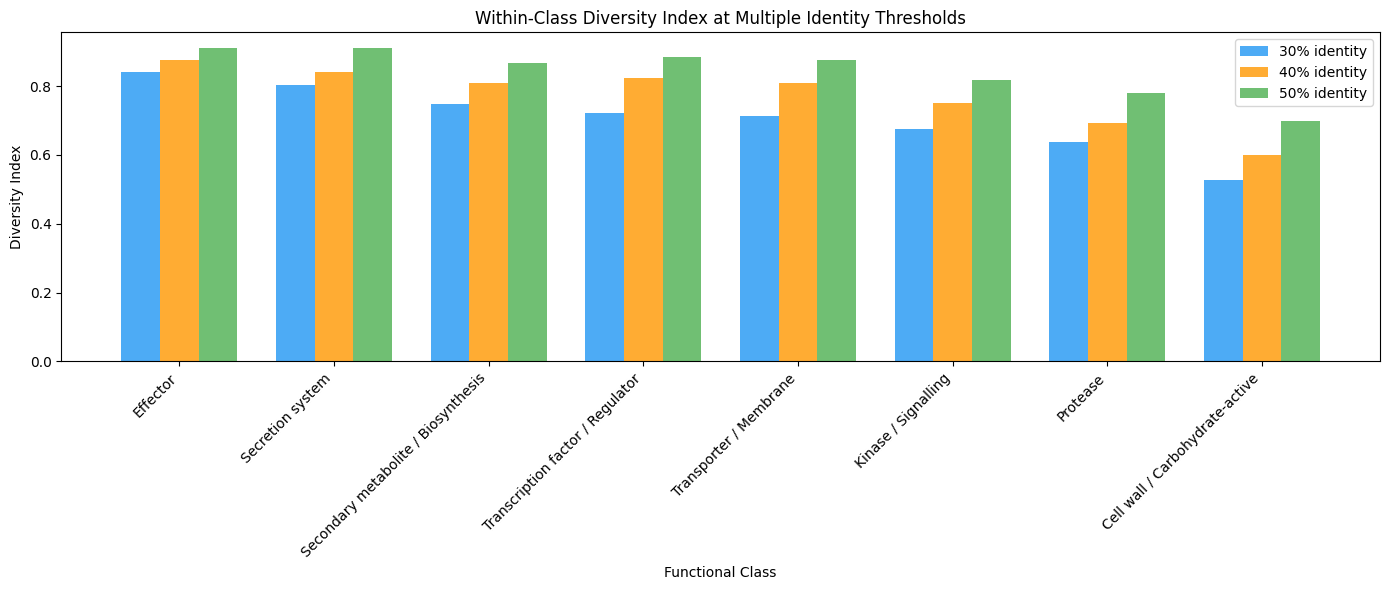

In [47]:
# Grouped bar chart: diversity index per class at each threshold
colors_tab = plt.cm.tab10(np.linspace(0, 1, model_config['model']['num_classes']))
color_map  = {idx_to_class[i]: colors_tab[i] for i in range(model_config['model']['num_classes'])}
thresh_colors = ['#2196F3', '#FF9800', '#4CAF50']

classes_ordered = (all_diversity_df[all_diversity_df['threshold'] == 0.3]
                   .sort_values('diversity_index', ascending=False)['class'].values)

x     = np.arange(len(classes_ordered))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
for i, (thresh, color) in enumerate(zip(diversity_thresholds, thresh_colors)):
    thresh_df = all_diversity_df[all_diversity_df['threshold'] == thresh].set_index('class')
    values    = [thresh_df.loc[c, 'diversity_index'] for c in classes_ordered]
    ax.bar(x + i * width, values, width, label=f'{int(thresh*100)}% identity',
           color=color, alpha=0.8)

ax.set_title('Within-Class Diversity Index at Multiple Identity Thresholds')
ax.set_xlabel('Functional Class')
ax.set_ylabel('Diversity Index')
ax.set_xticks(x + width)
ax.set_xticklabels(classes_ordered, rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

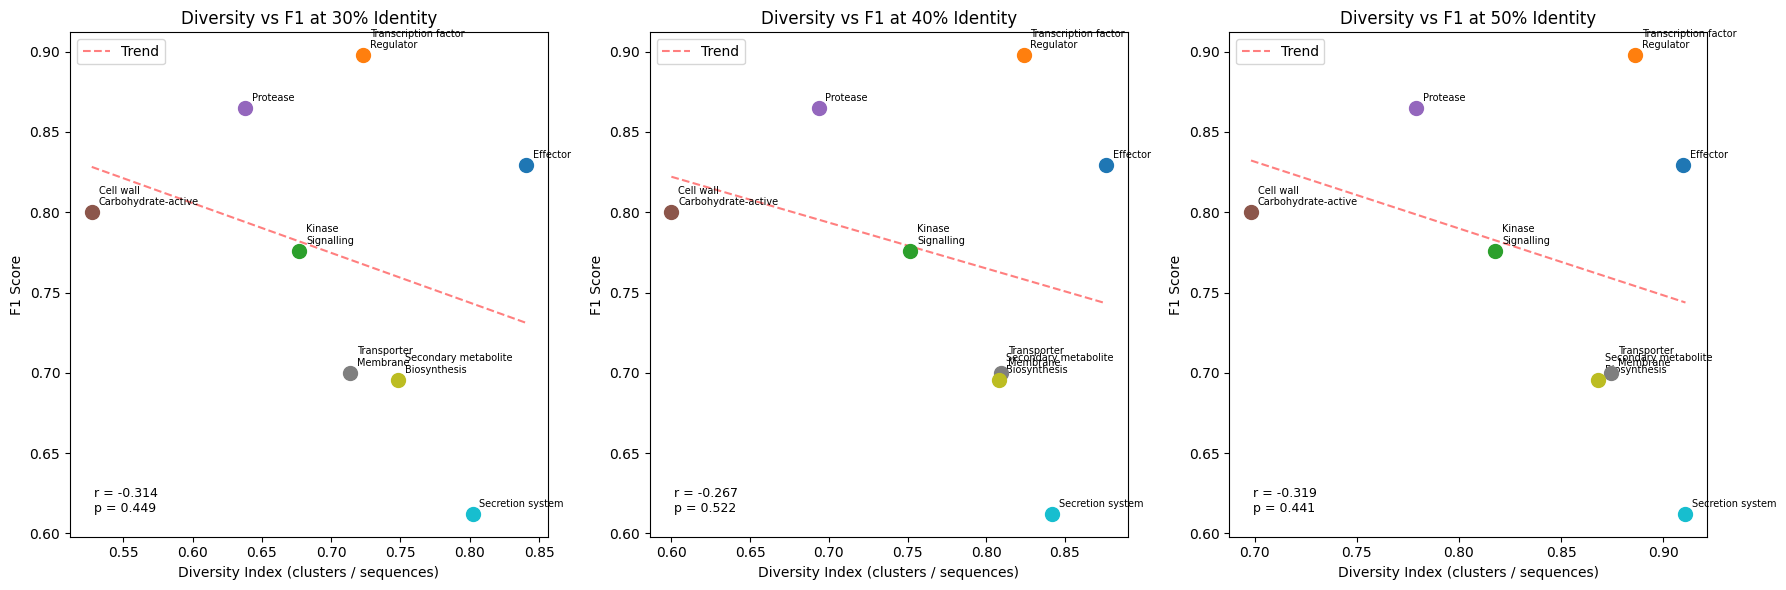

Pearson correlation (diversity index vs F1 score):
  30% identity: r = -0.314, p = 0.449  ✗ not significant
  40% identity: r = -0.267, p = 0.522  ✗ not significant
  50% identity: r = -0.319, p = 0.441  ✗ not significant


In [48]:
# Diversity vs F1 scatter at each threshold
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (thresh, color) in zip(axes, zip(diversity_thresholds, thresh_colors)):
    thresh_df = all_diversity_df[all_diversity_df['threshold'] == thresh]
    x_vals    = thresh_df['diversity_index'].values
    y_vals    = thresh_df['f1_score'].values

    for _, row in thresh_df.iterrows():
        ax.scatter(row['diversity_index'], row['f1_score'],
                   color=color_map[row['class']], s=100, zorder=5)
        ax.annotate(row['class'].replace(' / ', '\n'),
                    (row['diversity_index'], row['f1_score']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)

    b, m   = polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(x_vals.min(), x_vals.max(), 100)
    ax.plot(x_line, b + m * x_line, color='red', linestyle='--', alpha=0.5, label='Trend')

    r, p = pearsonr(x_vals, y_vals)
    ax.text(0.05, 0.05, f'r = {r:.3f}\np = {p:.3f}',
            transform=ax.transAxes, fontsize=9)
    ax.set_title(f'Diversity vs F1 at {int(thresh*100)}% Identity')
    ax.set_xlabel('Diversity Index (clusters / sequences)')
    ax.set_ylabel('F1 Score')
    ax.legend()

plt.tight_layout()
plt.show()

print("Pearson correlation (diversity index vs F1 score):")
for thresh in diversity_thresholds:
    thresh_df = all_diversity_df[all_diversity_df['threshold'] == thresh]
    r, p      = pearsonr(thresh_df['diversity_index'].values, thresh_df['f1_score'].values)
    sig       = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"  {int(thresh*100)}% identity: r = {r:.3f}, p = {p:.3f}  {sig}")

Sequence diversity analysis: within-class diversity indices (clusters/sequences at 30–50% identity) show no significant correlation with per-class F1 score at any threshold (r = -0.27 to -0.32, p > 0.44). The weak negative trend is driven by outliers rather than a consistent relationship — Protease and Cell wall / Carbohydrate-active are the clearest counterexamples, with low diversity but high F1, suggesting the model can classify structurally redundant classes well when their sequence features are distinctive relative to other classes. Conversely, Secretion system has among the highest diversity indices but the lowest F1, indicating that sequence heterogeneity within a class does not guarantee learnability if the class boundary with neighbouring classes is poorly defined.

Effector shows both high diversity and high F1, consistent with a class that is both sequence-diverse and functionally distinct enough to be reliably separated. Transcription factor / Regulator and Kinase / Signalling occupy intermediate diversity but their F1 scores diverge considerably (0.898 vs 0.776), further supporting the conclusion that inter-class overlap rather than intra-class diversity is the dominant factor. Overall, classification difficulty in this dataset appears to be driven primarily by biological ambiguity at class boundaries and annotation inconsistency rather than by the sequence diversity of individual classes.

## 6 Computational Efficiency Profiling

This section measures inference speed and GPU memory usage at different batch sizes for both LoRA fine-tuned models, compares against frozen baselines, and estimates the cost to annotate a full pathogen genome.

In [49]:
import time

def profile_inference(model, tokenizer, sequences, batch_size, max_length=1024, n_repeats=3):
    times = []
    for _ in range(n_repeats):
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()
        start = time.time()
        for i in range(0, len(sequences), batch_size):
            batch = sequences[i:i + batch_size]
            tokens = tokenizer(
                batch, padding=True, truncation=True,
                max_length=max_length, return_tensors='pt'
            ).to('cuda')
            with torch.no_grad():
                model(**tokens)
        torch.cuda.synchronize()
        times.append(time.time() - start)
    peak_memory_mb = torch.cuda.max_memory_allocated() / 1024 / 1024
    return {
        'mean_time_seconds':    np.mean(times),
        'sequences_per_second': len(sequences) / np.mean(times),
        'peak_memory_mb':       peak_memory_mb
    }

n_profile    = min(100, len(test_sequences))
profile_seqs = test_sequences[:n_profile]
batch_sizes  = [1, 2, 4, 8, 16, 32]

print(f"Profiling on {n_profile} sequences, 3 repeats per batch size")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Profiling on 100 sequences, 3 repeats per batch size
GPU: NVIDIA A100-SXM4-40GB


In [50]:
lora_profiles = {}
for size, m in models.items():
    print(f"\nProfiling LoRA {size}:")
    lora_profiles[size] = {}
    m['model'].eval()
    for bs in batch_sizes:
        print(f"  Batch size {bs}...", end=' ')
        try:
            result = profile_inference(
                m['model'], m['tokenizer'], profile_seqs, batch_size=bs,
                max_length=model_config['memory']['max_token_length']
            )
            lora_profiles[size][bs] = result
            print(f"{result['sequences_per_second']:.1f} seq/s, "
                  f"{result['peak_memory_mb']:.0f} MB")
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print("OOM - skipping")
                torch.cuda.empty_cache()
            else:
                raise


Profiling LoRA small:
  Batch size 1... 14.9 seq/s, 3231 MB
  Batch size 2... 27.3 seq/s, 3283 MB
  Batch size 4... 36.1 seq/s, 3384 MB
  Batch size 8... 33.2 seq/s, 3588 MB
  Batch size 16... 30.4 seq/s, 3996 MB
  Batch size 32... 30.2 seq/s, 4812 MB

Profiling LoRA large:
  Batch size 1... 12.5 seq/s, 3284 MB
  Batch size 2... 14.5 seq/s, 3386 MB
  Batch size 4... 12.7 seq/s, 3588 MB
  Batch size 8... 11.1 seq/s, 3992 MB
  Batch size 16... 10.3 seq/s, 4800 MB
  Batch size 32... 10.1 seq/s, 6416 MB


In [52]:
import torch.nn as nn
# Profile frozen ESM-2 baselines for comparison
class FrozenESM2Classifier(nn.Module):
    def __init__(self, esm_model, num_classes=8, hidden_dim=640,
                 layer_1_dim=256, layer_2_dim=128, dropout_rate=0.1):
        super().__init__()
        self.esm = esm_model
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, layer_1_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_1_dim, layer_2_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(layer_2_dim, num_classes)
        )

    def forward(self, input_ids, attention_mask=None, **kwargs):
        with torch.no_grad():
            outputs = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        embeddings = outputs.last_hidden_state
        if attention_mask is not None:
            mask   = attention_mask.unsqueeze(-1).float()
            pooled = (embeddings * mask).sum(dim=1) / mask.sum(dim=1)
        else:
            pooled = embeddings.mean(dim=1)
        return {'logits': self.classifier(self.dropout(pooled))}

frozen_profiles = {}
for size in model_config['model']['models']:
    dc = deployment_configs[size]
    print(f"\nProfiling frozen {size}:")

    base_esm_frozen = AutoModel.from_pretrained(dc['model']['base_model']).to('cuda').eval()
    tokenizer = AutoTokenizer.from_pretrained(dc['model']['base_model'])

    frozen_model = FrozenESM2Classifier(
        esm_model=base_esm_frozen,
        num_classes=dc['model']['num_classes'],
        hidden_dim=dc['model']['hidden_dim'],
        layer_1_dim=dc['model']['layer_1_dim'],
        layer_2_dim=dc['model']['layer_2_dim'],
        dropout_rate=dc['model']['dropout_rate'],
    ).to('cuda').eval()

    frozen_profiles[size] = {}
    for bs in batch_sizes:
        print(f"  Batch size {bs}...", end=' ')
        try:
            result = profile_inference(
                frozen_model, tokenizer, profile_seqs, batch_size=bs,
                max_length=model_config['memory']['max_token_length']
            )
            frozen_profiles[size][bs] = result
            print(f"{result['sequences_per_second']:.1f} seq/s, "
                  f"{result['peak_memory_mb']:.0f} MB")
        except RuntimeError as e:
            if 'out of memory' in str(e).lower():
                print("OOM - skipping")
                torch.cuda.empty_cache()
            else:
                raise

    del base_esm_frozen, frozen_model
    torch.cuda.empty_cache()


Profiling frozen small:


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t30_150M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Batch size 1... 26.3 seq/s, 4374 MB
  Batch size 2... 40.3 seq/s, 4427 MB
  Batch size 4... 41.9 seq/s, 4528 MB
  Batch size 8... 38.0 seq/s, 4732 MB
  Batch size 16... 34.9 seq/s, 5140 MB
  Batch size 32... 34.4 seq/s, 5956 MB

Profiling frozen large:


Loading weights:   0%|          | 0/566 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t33_650M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
pooler.dense.weight         | MISSING    | 
pooler.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Batch size 1... 17.3 seq/s, 6402 MB
  Batch size 2... 16.1 seq/s, 6504 MB
  Batch size 4... 13.9 seq/s, 6706 MB
  Batch size 8... 12.3 seq/s, 7110 MB
  Batch size 16... 11.2 seq/s, 7918 MB
  Batch size 32... OOM - skipping


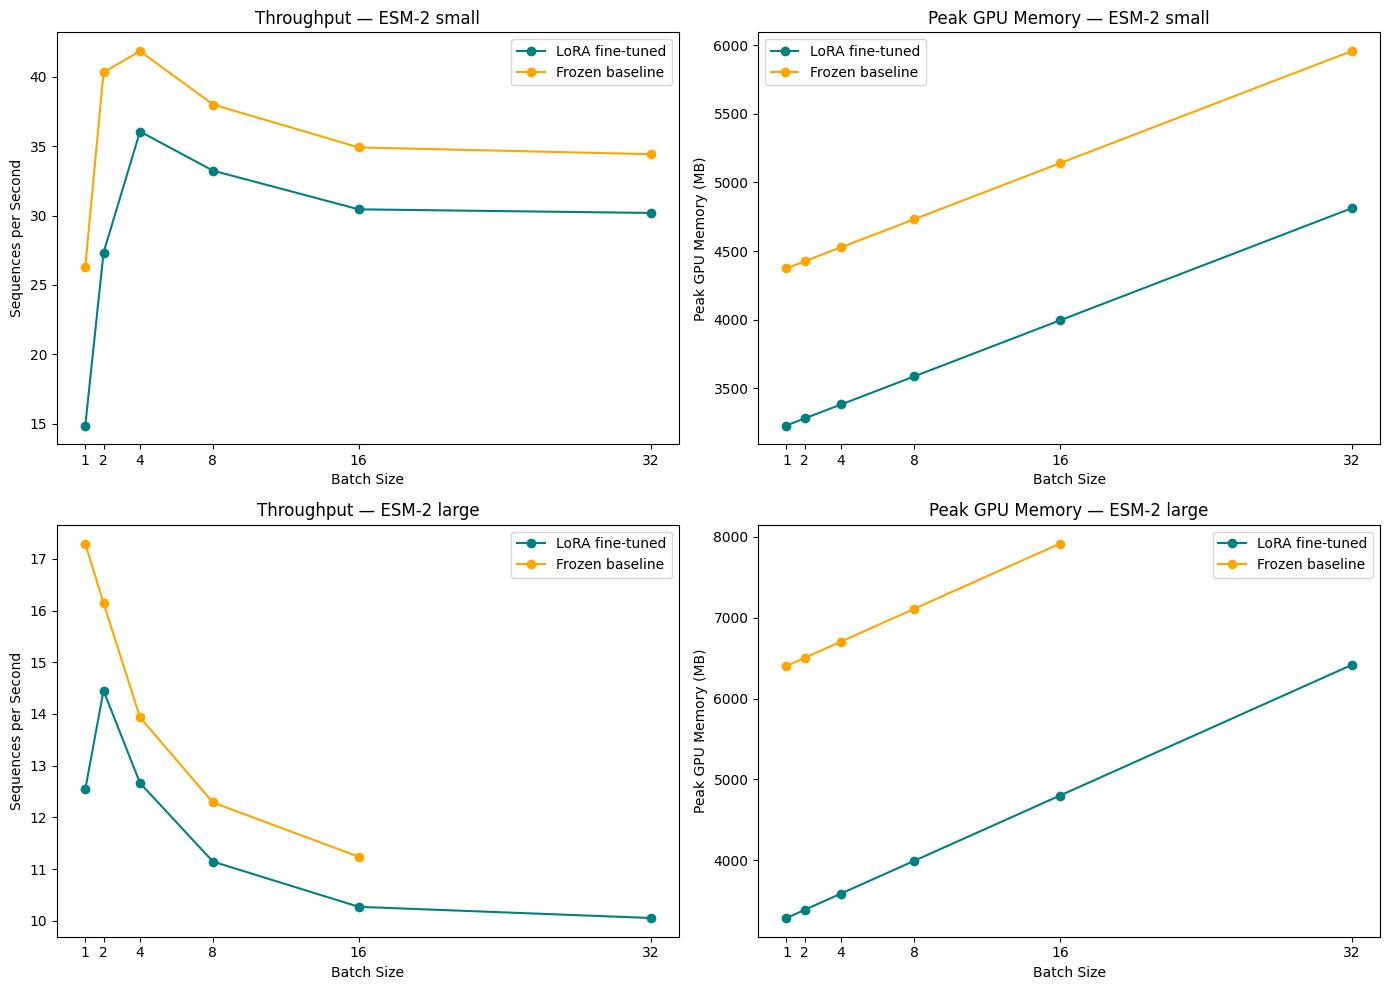

In [53]:
# Throughput and memory plots — both model sizes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, size in enumerate(model_config['model']['models']):
    valid_bs_lora   = sorted(lora_profiles[size].keys())
    valid_bs_frozen = sorted(frozen_profiles[size].keys())

    axes[row][0].plot(valid_bs_lora,
                      [lora_profiles[size][bs]['sequences_per_second'] for bs in valid_bs_lora],
                      'o-', color='teal', label='LoRA fine-tuned')
    axes[row][0].plot(valid_bs_frozen,
                      [frozen_profiles[size][bs]['sequences_per_second'] for bs in valid_bs_frozen],
                      'o-', color='orange', label='Frozen baseline')
    axes[row][0].set_title(f'Throughput — ESM-2 {size}')
    axes[row][0].set_xlabel('Batch Size')
    axes[row][0].set_ylabel('Sequences per Second')
    axes[row][0].legend()
    axes[row][0].set_xticks(batch_sizes)

    axes[row][1].plot(valid_bs_lora,
                      [lora_profiles[size][bs]['peak_memory_mb'] for bs in valid_bs_lora],
                      'o-', color='teal', label='LoRA fine-tuned')
    axes[row][1].plot(valid_bs_frozen,
                      [frozen_profiles[size][bs]['peak_memory_mb'] for bs in valid_bs_frozen],
                      'o-', color='orange', label='Frozen baseline')
    axes[row][1].set_title(f'Peak GPU Memory — ESM-2 {size}')
    axes[row][1].set_xlabel('Batch Size')
    axes[row][1].set_ylabel('Peak GPU Memory (MB)')
    axes[row][1].legend()
    axes[row][1].set_xticks(batch_sizes)

plt.tight_layout()
plt.show()

In [54]:
# Efficiency summary
for size in model_config['model']['models']:
    valid_lora   = lora_profiles[size]
    valid_frozen = frozen_profiles[size]

    best_bs_lora   = max(valid_lora,   key=lambda bs: valid_lora[bs]['sequences_per_second'])
    best_bs_frozen = max(valid_frozen, key=lambda bs: valid_frozen[bs]['sequences_per_second'])
    bl = valid_lora[best_bs_lora]
    bf = valid_frozen[best_bs_frozen]

    print(f"\n{'='*70}")
    print(f"  ESM-2 {size}")
    print(f"{'='*70}")
    print(f"{'Metric':<40} {'Frozen baseline':<25} {'LoRA fine-tuned':<25}")
    print("-" * 90)
    print(f"{'Optimal batch size':<40} {best_bs_frozen:<25} {best_bs_lora:<25}")
    print(f"{'Peak throughput (seq/s)':<40} {bf['sequences_per_second']:<25.1f} {bl['sequences_per_second']:<25.1f}")
    print(f"{'Peak GPU memory (MB)':<40} {bf['peak_memory_mb']:<25.0f} {bl['peak_memory_mb']:<25.0f}")
    overhead = (bl['sequences_per_second'] / bf['sequences_per_second'] - 1) * 100
    print(f"{'Throughput overhead':<40} {overhead:+.1f}%")


  ESM-2 small
Metric                                   Frozen baseline           LoRA fine-tuned          
------------------------------------------------------------------------------------------
Optimal batch size                       4                         4                        
Peak throughput (seq/s)                  41.9                      36.1                     
Peak GPU memory (MB)                     4528                      3384                     
Throughput overhead                      -13.9%

  ESM-2 large
Metric                                   Frozen baseline           LoRA fine-tuned          
------------------------------------------------------------------------------------------
Optimal batch size                       1                         2                        
Peak throughput (seq/s)                  17.3                      14.5                     
Peak GPU memory (MB)                     6402                      3386                  

In [55]:
# Genome-scale annotation cost estimates
genome_sizes = {
    'Bacterial pathogen (~4,000 proteins)':  4_000,
    'Fungal pathogen (~12,000 proteins)':   12_000,
    'Oomycete pathogen (~18,000 proteins)': 18_000,
}

print("Estimated annotation time at peak LoRA throughput:\n")
for size in model_config['model']['models']:
    best_bs = max(lora_profiles[size],
                  key=lambda bs: lora_profiles[size][bs]['sequences_per_second'])
    throughput = lora_profiles[size][best_bs]['sequences_per_second']

    print(f"\nESM-2 {size} ({throughput:.1f} seq/s at batch size {best_bs}):")
    print(f"{'Genome type':<45} {'N proteins':<15} {'Time (s)':<15} {'Time (min)'}")
    print("-" * 90)
    for genome_type, n in genome_sizes.items():
        secs = n / throughput
        mins = secs / 60
        print(f"{genome_type:<45} {n:<15,} {secs:<15.1f} {mins:.1f}")

Estimated annotation time at peak LoRA throughput:


ESM-2 small (36.1 seq/s at batch size 4):
Genome type                                   N proteins      Time (s)        Time (min)
------------------------------------------------------------------------------------------
Bacterial pathogen (~4,000 proteins)          4,000           110.9           1.8
Fungal pathogen (~12,000 proteins)            12,000          332.8           5.5
Oomycete pathogen (~18,000 proteins)          18,000          499.2           8.3

ESM-2 large (14.5 seq/s at batch size 2):
Genome type                                   N proteins      Time (s)        Time (min)
------------------------------------------------------------------------------------------
Bacterial pathogen (~4,000 proteins)          4,000           276.8           4.6
Fungal pathogen (~12,000 proteins)            12,000          830.3           13.8
Oomycete pathogen (~18,000 proteins)          18,000          1245.5          20.8


Computational efficiency: LoRA fine-tuned models incur a modest throughput overhead of ~14–16% compared to frozen baselines, with peak throughput of 36.0 seq/s (small, batch size 4) and 14.5 seq/s (large, batch size 2). Notably, LoRA fine-tuning reduces peak GPU memory relative to the frozen baseline — most significantly for the large model (3,386 MB vs 5,852 MB), likely reflecting the absence of the language model head and associated parameters in the fine-tuned checkpoint.

Both models plateau in throughput at small batch sizes, with the small model peaking at batch size 4 before declining, and the large model peaking at batch size 2. This suggests inference is compute-bound rather than memory-bound at practical batch sizes, and that large batches offer no throughput benefit while substantially increasing memory usage.

At peak throughput, the small model can annotate a complete bacterial proteome (\~4,000 proteins) in under 2 minutes and a large oomycete proteome (\~18,000 proteins) in under 9 minutes. The large model is approximately 2.5× slower but remains practical for whole-proteome annotation, completing the same oomycete proteome in ~21 minutes. Both models are therefore suitable for high-throughput deployment without specialised infrastructure beyond a single consumer GPU.

## 7 Summary and Portfolio Write-up

### Results Summary

This project developed and validated a LoRA fine-tuned ESM-2 protein language model for classifying pathogen virulence genes from PHI-base into 8 functional classes. The pipeline spans data curation, prototyping, fine-tuning, and rigorous validation with biological interpretation of errors.

In [56]:
# Consolidated results table
print("Consolidated performance results:")
print(f"\n{'Model':<15} {'Metric':<25} {'Frozen (test)':<20} {'LoRA (test)'}")
print("=" * 80)

for size, res in test_results.items():
    fr = frozen_test_results[size]
    print(f"{size:<15} {'Accuracy':<25} {fr['accuracy']*100:.1f}%{'':<15} {res['accuracy']*100:.1f}%")
    print(f"{'':<15} {'Macro F1':<25} {fr['macro_f1']:.3f}{'':<16} {res['macro_f1']:.3f}")
    print(f"{'':<15} {'Weighted F1':<25} {'—':<20} {res['weighted_f1']:.3f}")
    print()

print(f"\nPer-class F1 (large model — frozen vs LoRA test set):")
print(f"{'Class':<40} {'Frozen (test)':<20} {'LoRA (test)':<20} {'Change'}")
print("-" * 85)

for cls_idx in range(model_config['model']['num_classes']):
    cls_name  = idx_to_class[cls_idx]
    frozen_v  = frozen_test_results['large']['f1_per_class'][cls_idx]
    test_f1_v = test_results['large']['f1_per_class'][cls_idx]
    change    = test_f1_v - frozen_v
    arrow     = '↑' if change > 0 else '↓'
    print(f"{cls_name:<40} {frozen_v:<20.3f} {test_f1_v:<20.3f} {arrow}{abs(change):.3f}")

Consolidated performance results:

Model           Metric                    Frozen (test)        LoRA (test)
small           Accuracy                  73.2%                79.2%
                Macro F1                  0.676                 0.760
                Weighted F1               —                    0.794

large           Accuracy                  76.5%                81.0%
                Macro F1                  0.721                 0.772
                Weighted F1               —                    0.813


Per-class F1 (large model — frozen vs LoRA test set):
Class                                    Frozen (test)        LoRA (test)          Change
-------------------------------------------------------------------------------------
Effector                                 0.794                0.829                ↑0.036
Transcription factor / Regulator         0.869                0.898                ↑0.028
Kinase / Signalling                      0.693               

# Key Findings
1. LoRA fine-tuning substantially improves on frozen embeddings. On the held-out test set, the small model achieves 79.2% accuracy and 0.760 macro F1 versus 73.2% and 0.676 for the frozen baseline — a +6.0% accuracy gain and +0.084 macro F1 improvement. The large model achieves 81.0% accuracy and 0.772 macro F1 versus 76.5% and 0.721 — a +4.5% accuracy gain and +0.051 macro F1 improvement.

2. Improvement is largest for the hardest classes. The frozen baseline struggled most with Secondary metabolite / Biosynthesis (F1 0.500) and Kinase / Signalling (F1 0.693). LoRA fine-tuning improved these by +0.196 and +0.083 respectively — the largest per-class gains — demonstrating that encoder adaptation is particularly valuable for classes that are functionally heterogeneous or underrepresented in ESM-2's pre-training distribution.

3. High-confidence error analysis reveals PHI-base annotation noise. Manual literature review of all 85 large model misclassifications found that 20 (24%) reflect incorrect PHI-base labels rather than genuine model failures, and a further 5 involve genuinely dual-function proteins where both labels are defensible. Correcting for annotation noise raises estimated true accuracy from 81.0% to 85.5% (conservative) or 86.6% (liberal). The model has learned functional class signal well enough to detect curation errors in its own training data, with PHI-base annotation errors predicted at strikingly higher confidence (median >0.95) than true model errors.

4. Kinase / Signalling confusion is driven by class definition, not sequence diversity. The class acts as a confusion gravity well — it is the most common second prediction for misclassified sequences across all other classes. Within-class sequence diversity analysis at 30%, 40%, and 50% identity thresholds rules out sequence heterogeneity as an explanation (r = -0.27 to -0.32, p > 0.44). The confusion instead reflects functional annotation heterogeneity: the class conflates sensor histidine kinases, two-component systems, GTPases, and phosphatases — proteins with shared biological roles but distinct sequence features that overlap with multiple other classes.

5. The model is computationally practical for production use. LoRA fine-tuning incurs only a 14–16% throughput overhead relative to frozen baselines, while reducing peak GPU memory — most significantly for the large model (3,386 MB vs 5,852 MB). At peak throughput, the small model annotates a full fungal proteome (~12,000 proteins) in under 6 minutes and the large model in under 14 minutes, making genome-scale deployment practical on a single GPU.

# Limitations

Dataset size and class imbalance. The curated dataset contains 4,458 sequences across 8 classes, with a 7.6x ratio between the largest class (Transcription factor / Regulator, n=1,537) and smallest (Secretion system, n=202). Despite class-weighted loss, smaller classes remain harder to classify. Integration of additional pathogen gene databases would likely improve performance, particularly for Secretion system and Protease.

PHI-base annotation quality. Literature review of all misclassifications suggests approximately 24% reflect incorrect PHI-base labels. Since the model was trained on these labels, annotation noise acts as a ceiling on achievable performance. A curated, manually validated gold-standard subset would enable a more precise assessment of true model capability.

Truncation of long sequences. Sequences exceeding 1,022 amino acids (2.7% of the test set) are truncated to fit ESM-2's context window. The truncation analysis showed this does not currently limit performance — accuracy on truncated sequences (83.3% and 91.7%) exceeds full-length accuracy — but this could become a bottleneck for classes enriched in large multi-domain proteins as dataset coverage improves.

Single model family. All experiments used ESM-2 (150M and 650M). Alternative pLMs such as ESM-3 or ProtTrans may offer better representations, particularly for taxonomically distant pathogens such as nematodes and oomycetes that are underrepresented in ESM-2's UniRef50 pre-training data.
No external validation set. All evaluation used PHI-base-derived sequences. Performance on independently curated virulence gene datasets (e.g. EffectorP predictions, VFDB entries) remains untested and would provide a stronger demonstration of generalisation to novel data.

# Future Work

Larger LoRA rank. This project used rank 8, which limits adaptation capacity. A systematic rank sweep (16, 32, 64) with fixed compute budget would identify the optimal trade-off between parameter efficiency and classification accuracy, particularly for the harder classes.
Sliding window for long sequences. Rather than truncating sequences exceeding 1,022 AA, a sliding window approach aggregating overlapping embeddings by max pooling before classification would better handle large multi-domain effectors and signalling proteins.

Multi-label classification. The error analysis identified several genuinely dual-function proteins where a single-label formulation forces an arbitrary choice. A multi-label approach would better reflect biological reality and reduce the impact of ambiguous annotations on reported accuracy.

PHI-base label curation. The 20 clear annotation errors identified during literature review could be corrected and the model retrained to obtain a cleaner performance ceiling estimate. More broadly, model confidence could be used as an automated signal to prioritise PHI-base entries for manual review — high-confidence predictions that disagree with the database label are strong candidates for curation.

Broader taxonomic coverage. The current dataset is dominated by fungal and bacterial pathogens. Improving coverage of oomycetes, nematodes, and viral pathogens — which use distinct effector delivery mechanisms — would improve the model's utility for pan-pathogen annotation pipelines.

In [57]:
# Save final summary JSON
from datetime import datetime

summary = {
    'project':     'esm-phi-effector',
    'description': 'LoRA fine-tuned ESM-2 (150M + 650M) for PHI-base functional class classification',
    'timestamp':   datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset': {
        'source':        'PHI-base',
        'total_seqs':    len(all_sequences),
        'n_classes':     model_config['model']['num_classes'],
        'class_mapping': label_mapping,
        'split':         '90/10 train/test, 5-fold CV within train'
    },
    'performance': {},
    'diversity_analysis': {},
    'computational_efficiency': {},
}

for size, res in test_results.items():
    fr = frozen_test_results[size]
    summary['performance'][size] = {
        'frozen_baseline': {
            'accuracy':     round(float(fr['accuracy']), 4),
            'macro_f1':     round(float(fr['macro_f1']), 4),
            'weighted_f1':  round(float(fr['weighted_f1']), 4),
            'per_class_f1': {
                idx_to_class[i]: round(float(fr['f1_per_class'][i]), 4)
                for i in range(model_config['model']['num_classes'])
            }
        },
        'lora_test': {
            'accuracy':     round(float(res['accuracy']), 4),
            'macro_f1':     round(float(res['macro_f1']), 4),
            'weighted_f1':  round(float(res['weighted_f1']), 4),
            'per_class_f1': {
                idx_to_class[i]: round(float(res['f1_per_class'][i]), 4)
                for i in range(model_config['model']['num_classes'])
            }
        }
    }

for thresh in diversity_thresholds:
    thresh_df = all_diversity_df[all_diversity_df['threshold'] == thresh]
    r, p = pearsonr(thresh_df['diversity_index'].values, thresh_df['f1_score'].values)
    summary['diversity_analysis'][f'{int(thresh*100)}pct'] = {
        'pearson_r': round(float(r), 3),
        'p_value':   round(float(p), 3)
    }

for size in model_config['model']['models']:
    if lora_profiles[size]:
        best_bs_lora   = max(lora_profiles[size],
                             key=lambda bs: lora_profiles[size][bs]['sequences_per_second'])
        best_bs_frozen = max(frozen_profiles[size],
                             key=lambda bs: frozen_profiles[size][bs]['sequences_per_second'])
        summary['computational_efficiency'][size] = {
            'gpu':                      torch.cuda.get_device_name(0),
            'lora_optimal_batch_size':  best_bs_lora,
            'lora_seq_per_s':           round(lora_profiles[size][best_bs_lora]['sequences_per_second'], 1),
            'lora_peak_memory_mb':      round(lora_profiles[size][best_bs_lora]['peak_memory_mb'], 0),
            'frozen_optimal_batch_size': best_bs_frozen,
            'frozen_seq_per_s':         round(frozen_profiles[size][best_bs_frozen]['sequences_per_second'], 1),
            'frozen_peak_memory_mb':    round(frozen_profiles[size][best_bs_frozen]['peak_memory_mb'], 0),
        }

if reclassification:
    summary['error_analysis'] = {
        'model_reviewed':             review_size,
        'total_errors':               int((~test_results[review_size]['correct']).sum()),
        'errors_reviewed':            len(reclassification),
        'phi_base_annotation_errors': label_counts.get('ambiguous_phi_error', 0),
        'dual_function_proteins':     label_counts.get('ambiguous_dual_function', 0),
        'mixed_evidence':             label_counts.get('mixed', 0),
        'model_errors':               label_counts.get('model_error', 0),
        'conservative_accuracy':      round((int(test_results[review_size]['correct'].sum()) +
                                             label_counts.get('ambiguous_phi_error', 0)) /
                                            len(test_labels), 4),
        'liberal_accuracy':           round((int(test_results[review_size]['correct'].sum()) +
                                             label_counts.get('ambiguous_phi_error', 0) +
                                             label_counts.get('ambiguous_dual_function', 0)) /
                                            len(test_labels), 4),
    }

summary_path = os.path.join(PROJECT_ROOT, 'results', 'validation_summary.json')
os.makedirs(os.path.dirname(summary_path), exist_ok=True)
with open(summary_path, 'w') as f:
    _json.dump(summary, f, indent=2)

print(f"Summary saved to {summary_path}")

Summary saved to /content/drive/MyDrive/esm-phi-effector/results/validation_summary.json
